In [3]:
import numpy as np
import pandas as pd
import scanpy as sc

import plotnine as p9

import liana as li
import decoupler as dc
import omnipath as op

# Import DESeq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import muon as mu
from muon import MuData

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [4]:
# Obtain TF regulons
net = dc.op.collectri(organism='human', remove_complexes=False, license='academic', verbose=False)

# Load & Prep Data

In [5]:
mdata_sepsis = mu.read("/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/python_objekte/gated_sepsis_with_metadata.h5mu")

mdata_sepsis

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/mudata/_core/mudata.py:613: UserWarning: Cannot join columns with the same name because var_names are intersecting.


MuData object with n_obs × n_vars = 285043 × 37679
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'sample', 'donor_id', 'cell_barcodes', 'scRNA.seq', 'TCR', 'BCR', 'CITE.seq', 'Bulk.RNA.seq', 'Olink.proteomics', 'Gender', 'Age', 'Sample.Collection.Date', 'Sample.Collection.Site', 'Group', 'Sepsis.Infection.Source', 'Ethnicity', 'Chronic.comorbidity.None', 'Cardiovascular.compromise', 'COPD', 'Hypertension', 'Diabetes', 'Respiratory.insufficiency', 'Renal.insufficiency', 'Tuberculosis', 'Length.of.ICU.stay.days', 'Length.of.hospital.stay.days', 'X14.day.mortality..Deceased.1.Living.0.', 'X28.day.mortality..Deceased.1.Living.0.', 'X90.day.mortality..Deceased.1.Living.0.', 'Gram.positive.bacteria', 'Gram.negative.bacteria', 'Virus', 'Fungi', 'Microbiology.laboratory..Unknown', 'SOFA.score', 'Shock', 'Organ.failure', 'Mechanical.ventilation', 'percent.mt', 'percent.ribo', 'percent.hb', 'mt_outlier_all', 'is_outlier_RNA', 'is_outlier_protein', 'is_outlier', 'scDblFinder.class', 'scDblFinder.score', 'RNA_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.25', 'RNA.weight', 'ADT.weight', 'leiden_0.8_totalVI', 'leiden_0.25_totalVI', 'celltype_full', 'lineage', 'pla_status', 'celltype', 'Dataset', 'Cohort', 'Condition', 'Sex', 'Ethnicity_Race', 'inner_batch_effect', 'patient_ID', 'sample_ID'
  2 modalities
    rna:	285043 × 37471
    adt:	285043 × 208

In [6]:
object_sepsis = "Sepsis"

Define cols of interest from .obs.

In [7]:
mdata_sepsis.obs[["patient_ID", "sample", "sample_ID"]]

,patient_ID,sample,sample_ID
GSM8571042_Abd-S111_AAACCTGAGCAGCCTC-1,Abd-S111,GSM8571042_Abd-S111,GSM8571042_Abd-S111
GSM8571042_Abd-S111_AAACCTGAGCGAAGGG-1,Abd-S111,GSM8571042_Abd-S111,GSM8571042_Abd-S111
GSM8571042_Abd-S111_AAACCTGAGCGGCTTC-1,Abd-S111,GSM8571042_Abd-S111,GSM8571042_Abd-S111
GSM8571042_Abd-S111_AAACCTGAGTGTACTC-1,Abd-S111,GSM8571042_Abd-S111,GSM8571042_Abd-S111
GSM8571042_Abd-S111_AAACCTGCAGGGCATA-1,Abd-S111,GSM8571042_Abd-S111,GSM8571042_Abd-S111
...,...,...,...
GSM8571081_Uri-S88_TTTGTCAGTGCTAGCC-1,Uri-S88,GSM8571081_Uri-S88,GSM8571081_Uri-S88
GSM8571081_Uri-S88_TTTGTCATCAAGATCC-1,Uri-S88,GSM8571081_Uri-S88,GSM8571081_Uri-S88
GSM8571081_Uri-S88_TTTGTCATCCCTCAGT-1,Uri-S88,GSM8571081_Uri-S88,GSM8571081_Uri-S88
GSM8571081_Uri-S88_TTTGTCATCGCTAGCG-1,Uri-S88,GSM8571081_Uri-S88,GSM8571081_Uri-S88


sample + sample_ID are identical

In [8]:
# sepsis
base_sample_key = 'sample'
groupby = 'lineage' # for pseudobulk profiles
condition_key = 'pla_status'

# Differential Testing

In [9]:
adata_sepsis = mdata_sepsis["rna"].copy()

cols = ["sample", "patient_ID", "lineage", "pla_status"]
adata_sepsis.obs[cols] = mdata_sepsis.obs.loc[adata_sepsis.obs_names, cols]

# merge missing celltypes into Unassigned
adata_sepsis.obs[groupby] = adata_sepsis.obs[groupby].fillna("Unassigned")

# missing condition to platelet-free
adata_sepsis.obs[condition_key] = adata_sepsis.obs[condition_key].fillna("platelet-free")

# one pseudobulk replicate for every biological sample × PLA state
adata_sepsis.obs["pb_sample"] = (
    adata_sepsis.obs["sample"].astype(str)
    + "__"
    + adata_sepsis.obs["pla_status"].astype(str)
)

sample_key = "pb_sample"

In [10]:
print(adata_sepsis.obs["pb_sample"])

cell_barcode
GSM8571042_Abd-S111_AAACCTGAGCAGCCTC-1    GSM8571042_Abd-S111__platelet-free
GSM8571042_Abd-S111_AAACCTGAGCGAAGGG-1    GSM8571042_Abd-S111__platelet-free
GSM8571042_Abd-S111_AAACCTGAGCGGCTTC-1    GSM8571042_Abd-S111__platelet-free
GSM8571042_Abd-S111_AAACCTGAGTGTACTC-1    GSM8571042_Abd-S111__platelet-free
GSM8571042_Abd-S111_AAACCTGCAGGGCATA-1    GSM8571042_Abd-S111__platelet-free
                                                         ...                
GSM8571081_Uri-S88_TTTGTCAGTGCTAGCC-1                GSM8571081_Uri-S88__PLA
GSM8571081_Uri-S88_TTTGTCATCAAGATCC-1      GSM8571081_Uri-S88__platelet-free
GSM8571081_Uri-S88_TTTGTCATCCCTCAGT-1                GSM8571081_Uri-S88__PLA
GSM8571081_Uri-S88_TTTGTCATCGCTAGCG-1                GSM8571081_Uri-S88__PLA
GSM8571081_Uri-S88_TTTGTCATCTGGCGTG-1      GSM8571081_Uri-S88__platelet-free
Name: pb_sample, Length: 285043, dtype: object


In [11]:
pdata_sepsis = dc.pp.pseudobulk(
    adata_sepsis,
    sample_col=sample_key,
    groups_col=groupby,
    layer=None,
    mode="sum"
)

pdata_sepsis

AnnData object with n_obs × n_vars = 640 × 37471
    obs: 'pb_sample', 'lineage', 'sample', 'patient_ID', 'pla_status', 'psbulk_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [12]:
for min_cells in [1, 3, 5, 10]:
    
    keep = (
        (pdata_sepsis.obs["psbulk_cells"] >= min_cells) &
        (pdata_sepsis.obs["psbulk_counts"] >= 1000) &
        (pdata_sepsis.obs["pla_status"] == "PLA")
    )
    
    print(f"\nmin_cells = {min_cells}")
    print(
        pdata_sepsis.obs.loc[keep]
        .groupby("lineage", observed=True)
        .size()
    )


min_cells = 1
lineage
B cells        40
CD4 T cells    40
CD8 T cells    40
DCs            40
Monocytes      40
NK cells       40
dtype: int64

min_cells = 3
lineage
B cells        37
CD4 T cells    40
CD8 T cells    40
DCs            38
Monocytes      40
NK cells       40
dtype: int64

min_cells = 5
lineage
B cells        36
CD4 T cells    40
CD8 T cells    40
DCs            37
Monocytes      40
NK cells       39
dtype: int64

min_cells = 10
lineage
B cells        24
CD4 T cells    40
CD8 T cells    40
DCs            35
Monocytes      40
NK cells       36
dtype: int64


In [13]:
# filter samples based on number of cells and counts
dc.pp.filter_samples(pdata_sepsis, min_cells = 5, min_counts=1000)

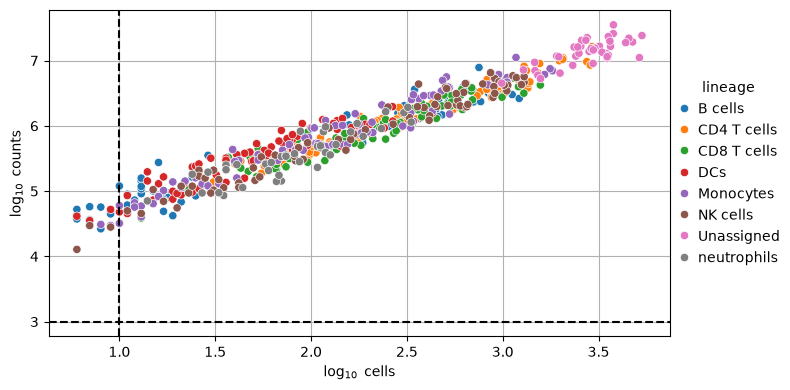

In [14]:
dc.pl.filter_samples(
    pdata_sepsis,
    groupby=groupby,
    figsize=(8, 4)
)

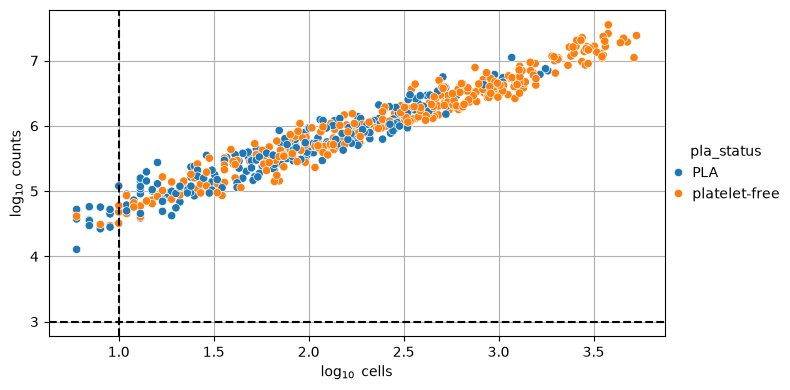

In [15]:
dc.pl.filter_samples(
    pdata_sepsis,
    groupby=condition_key,
    figsize=(8, 4)
)

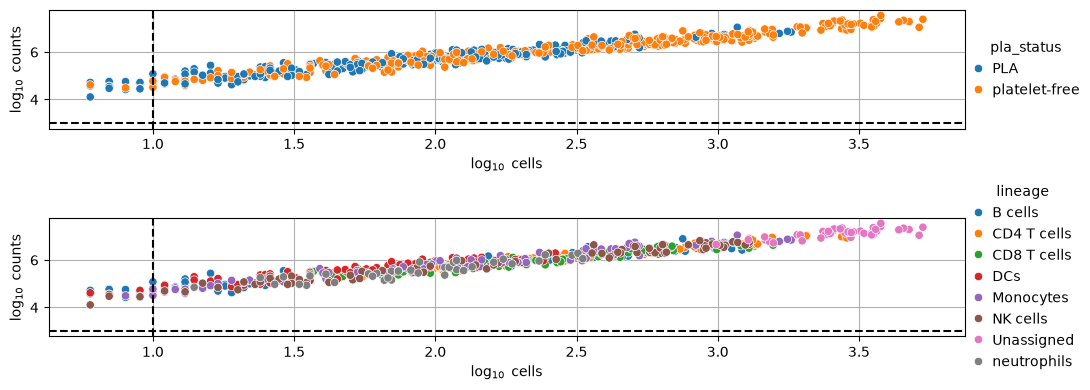

In [16]:
dc.pl.filter_samples(pdata_sepsis, groupby=[condition_key, groupby], figsize=(11, 4))

x = how many single cells contributed to that pseudobulk
y = total RNA counts summed across those cells

In [17]:
pdata_sepsis.obs.groupby(groupby)["psbulk_cells"].describe()

,count,mean,std,min,25%,50%,75%,max
lineage,,,,,,,,
B cells,76.0,279.828947,366.970858,5.0,12.00,115.0,466.75,1982.0
CD4 T cells,80.0,634.112500,687.532756,30.0,118.75,293.0,963.75,2918.0
CD8 T cells,80.0,336.300000,314.973714,12.0,108.50,256.5,483.75,1570.0
DCs,77.0,74.415584,74.636549,5.0,24.00,51.0,95.00,428.0
Monocytes,80.0,305.887500,408.594658,7.0,38.75,138.0,394.00,1819.0
NK cells,79.0,433.000000,526.812743,5.0,41.00,267.0,640.50,3485.0
Unassigned,40.0,2937.600000,1042.642275,987.0,2347.50,2899.0,3554.75,5327.0
neutrophils,40.0,105.250000,81.893849,13.0,53.50,77.0,119.75,332.0


In [18]:
tmp = (
    pdata_sepsis.obs
    .groupby(["sample", "lineage", "pla_status"], observed=True)
    .size()
    .unstack("pla_status", fill_value=0)
)

tmp

pla_status                       PLA  platelet-free
sample              lineage                        
GSM8571042_Abd-S111 B cells        1              1
                    CD4 T cells    1              1
                    CD8 T cells    1              1
                    DCs            1              1
                    Monocytes      1              1
...                              ...            ...
GSM8571081_Uri-S88  DCs            1              1
                    Monocytes      1              1
                    NK cells       1              1
                    Unassigned     0              1
                    neutrophils    0              1

[320 rows x 2 columns]

# Differential Expression Analysis

- edgeR-like filtering using decoupler-py
- then differential expression analysis using pydeseq2 package
- re-implementation of the original DESeq2 method

sequencing reads -> UMI counts per gene per cell -> sum across cells -> pseudobulk gene counts per patient/sample

In [20]:
for ct in pdata_sepsis.obs[groupby].unique():

    tmp = pdata_sepsis.obs[pdata_sepsis.obs[groupby] == ct]

    tab = pd.crosstab(
        tmp["sample"],
        tmp["pla_status"]
    )

    complete = (
        (tab.get("PLA", 0) > 0) &
        (tab.get("platelet-free", 0) > 0)
    )

    print(
        ct,
        "| complete pairs:", complete.sum(),
        "| patients:", len(tab),
        "| PLA:", (tmp["pla_status"] == "PLA").sum(),
        "| platelet-free:", (tmp["pla_status"] == "platelet-free").sum()
    )

B cells | complete pairs: 36 | patients: 40 | PLA: 36 | platelet-free: 40
CD4 T cells | complete pairs: 40 | patients: 40 | PLA: 40 | platelet-free: 40
CD8 T cells | complete pairs: 40 | patients: 40 | PLA: 40 | platelet-free: 40
DCs | complete pairs: 37 | patients: 40 | PLA: 37 | platelet-free: 40
Monocytes | complete pairs: 40 | patients: 40 | PLA: 40 | platelet-free: 40
NK cells | complete pairs: 39 | patients: 40 | PLA: 39 | platelet-free: 40
Unassigned | complete pairs: 0 | patients: 40 | PLA: 0 | platelet-free: 40
neutrophils | complete pairs: 0 | patients: 40 | PLA: 0 | platelet-free: 40


Sepsis: We can do paired analysis. We have many complete pairs for almost all of the lineages. Thus we can also design DESeq with patient_ID and pla_status to remove patient-specific baseline differences and estimates the PLA effect from within-patient contrasts.

In [21]:
dea_results_sepsis = {}
quiet = True
min_complete_pairs = 5

for cell_group in pdata_sepsis.obs[groupby].unique():

    ctdata = pdata_sepsis[pdata_sepsis.obs[groupby] == cell_group].copy()

    # define condition categories
    ctdata.obs[condition_key] = (
        ctdata.obs[condition_key]
        .astype("category")
        .cat.set_categories(
            ["platelet-free", "PLA"],
            ordered=True
        )
    )

    # identify complete pairs
    pair_table = pd.crosstab(
        ctdata.obs["patient_ID"],
        ctdata.obs[condition_key]
    )

    complete = (
        (pair_table.get("PLA", 0) > 0) &
        (pair_table.get("platelet-free", 0) > 0)
    )

    complete_patients = pair_table.index[complete]
    n_complete_pairs = len(complete_patients)

    print(
        f"{cell_group} | "
        f"complete pairs: {n_complete_pairs}"
    )

    if n_complete_pairs < min_complete_pairs:
        print(
            f"Skipping DE for {cell_group}: "
            f"only {n_complete_pairs} complete patient pairs"
        )
        continue

    # keep only sufficient
    ctdata = ctdata[
        ctdata.obs["patient_ID"].isin(complete_patients)
    ].copy()

    # condition reference level
    ctdata.obs[condition_key] = (
        ctdata.obs[condition_key]
        .astype("category")
        .cat.set_categories(
            ["platelet-free", "PLA"],
            ordered=True
        )
    )

    print(
        f"Using {ctdata.n_obs} pseudobulks "
        f"from {n_complete_pairs} paired patients"
    )

    print(
        ctdata.obs[condition_key].value_counts()
    )

   # filter genes after selecting samples
    dc.pp.filter_by_expr(
        ctdata,
        group=condition_key,
        min_count=5,
        min_total_count=10
    )

    print(f"Genes after filtering: {ctdata.n_vars}")

   # paired DESeq2
    dds = DeseqDataSet(
        adata=ctdata,
        design="~ patient_ID + pla_status", # separate the patient-to-patient baseline differences from the systematic PLA effect
        refit_cooks=True,
        quiet=quiet
    )

    dds.deseq2()

    # PLA versus platelet-free
    stat_res = DeseqStats(
        dds,
        contrast=[
            condition_key,
            "PLA",
            "platelet-free"
        ],
        quiet=quiet
    )

    stat_res.summary()

    # shrink LFC
    stat_res.lfc_shrink(
        coeff="pla_status[T.PLA]"
    )

    dea_results_sepsis[cell_group] = stat_res.results_df

B cells | complete pairs: 36
Using 72 pseudobulks from 36 paired patients
pla_status
platelet-free    36
PLA              36
Name: count, dtype: int64
Genes after filtering: 6741


/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.


CD4 T cells | complete pairs: 40
Using 80 pseudobulks from 40 paired patients
pla_status
platelet-free    40
PLA              40
Name: count, dtype: int64
Genes after filtering: 10189
CD8 T cells | complete pairs: 40
Using 80 pseudobulks from 40 paired patients
pla_status
platelet-free    40
PLA              40
Name: count, dtype: int64
Genes after filtering: 9618
DCs | complete pairs: 37
Using 74 pseudobulks from 37 paired patients
pla_status
platelet-free    37
PLA              37
Name: count, dtype: int64
Genes after filtering: 6988


/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.


Monocytes | complete pairs: 40
Using 80 pseudobulks from 40 paired patients
pla_status
platelet-free    40
PLA              40
Name: count, dtype: int64
Genes after filtering: 8718
NK cells | complete pairs: 39
Using 78 pseudobulks from 39 paired patients
pla_status
platelet-free    39
PLA              39
Name: count, dtype: int64
Genes after filtering: 10223


/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.


Unassigned | complete pairs: 0
Skipping DE for Unassigned: only 0 complete patient pairs
neutrophils | complete pairs: 0
Skipping DE for neutrophils: only 0 complete patient pairs


In [23]:
# concat results across cell types
dea_df_sepsis = pd.concat(
    dea_results_sepsis,
    names=[groupby, "gene"]
)

dea_df_sepsis = dea_df_sepsis.reset_index(level=0)

dea_df_sepsis.head()

,lineage,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,,
THAP3,B cells,6.031176,-0.559637,0.292345,-2.030187,0.042338,0.077218
CPTP,B cells,8.682915,-0.331928,0.187497,-1.545254,0.122285,0.187346
DNAJC11,B cells,5.736828,-0.214355,0.198254,-1.007035,0.313918,0.408754
LZIC,B cells,10.616068,0.238998,0.153497,1.530563,0.125878,0.192108
MTHFR,B cells,6.932289,0.299029,0.182717,1.615276,0.106251,0.166955


In [24]:
# PyDeseq Seems to intrdoce NAs for some p-values
# NOTE: there sometimes some NaN being introduced, best to double check that
len(dea_df_sepsis[dea_df_sepsis.isna().any(axis=1)])
dea_df_sepsis.isna().sum().sort_values(ascending=False)

lineage           0
baseMean          0
log2FoldChange    0
lfcSE             0
stat              0
pvalue            0
padj              0
dtype: int64

In [25]:
print(
    f"{dea_df_sepsis.isna().any(axis=1).sum()} / {len(dea_df_sepsis)} "
    f"({dea_df_sepsis.isna().any(axis=1).mean():.2%})"
)

0 / 52477 (0.00%)


# DEA to Ligand-Receptor Interactions

In [26]:
adata_lr_sepsis = mdata_sepsis["rna"].copy()

# copy required metadata into RNA AnnData
cols = [condition_key, groupby]
adata_lr_sepsis.obs[cols] = mdata_sepsis.obs.loc[adata_lr_sepsis.obs_names, cols]

# keep only PLA cells
adata_lr_sepsis = adata_lr_sepsis[
    adata_lr_sepsis.obs[condition_key] == "PLA"
].copy()

# normalize RNA expression for LIANA expression/proportion calculations
sc.pp.normalize_total(adata_lr_sepsis, target_sum=1e4)
sc.pp.log1p(adata_lr_sepsis)

In [27]:
lr_res_sepsis = li.multi.df_to_lr(
    adata_lr_sepsis,
    dea_df=dea_df_sepsis,
    resource_name="consensus",
    expr_prop=0.1,
    groupby=groupby,
    stat_keys=["stat", "pvalue", "padj"],
    use_raw=False,
    complex_col="stat",
    verbose=True,
    return_all_lrs=False,
)

lr_res_sepsis = lr_res_sepsis.sort_values(
    "interaction_stat",
    ascending=False,
    key=abs
)

lr_res_sepsis.head()

Using resource `consensus`.
Using `.X`!
12537 features of mat are empty, they will be removed.
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:164: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
Features in adata and dea_df are mismatched.
0.66 of entities in the resource are missing from the data.


,ligand,receptor,ligand_complex,receptor_complex,source,ligand_stat,ligand_pvalue,ligand_padj,ligand_expr,ligand_props,...,receptor_pvalue,receptor_padj,receptor_expr,receptor_props,interaction_stat,interaction_pvalue,interaction_padj,interaction_expr,interaction_props,interaction
14,ANXA1,FPR1,ANXA1,FPR1,B cells,25.838900,3.242902e-147,4.372081e-144,0.854694,0.440574,...,2.373276e-90,2.666375e-88,0.646531,0.391393,22.997561,1.186638e-90,1.333188e-88,0.750613,0.415984,ANXA1^FPR1
85,S100A9,CD36,S100A9,CD36,B cells,24.678704,1.810908e-134,1.525917e-131,3.020891,0.733607,...,3.507610e-97,5.140173e-95,0.557917,0.362705,22.799444,1.753805e-97,2.570087e-95,1.789404,0.548156,S100A9^CD36
106,S100A12,CD36,S100A12,CD36,B cells,24.312884,1.432498e-130,1.072941e-127,1.433776,0.485656,...,3.507610e-97,5.140173e-95,0.557917,0.362705,22.616534,1.753805e-97,2.570087e-95,0.995847,0.424180,S100A12^CD36
83,S100A9,TLR4,S100A9,TLR4,B cells,24.678704,1.810908e-134,1.525917e-131,3.020891,0.733607,...,9.520350e-90,1.018677e-87,0.208033,0.186475,22.383028,4.760175e-90,5.093387e-88,1.614462,0.460041,S100A9^TLR4
127,ANXA1,DYSF,ANXA1,DYSF,B cells,25.838900,3.242902e-147,4.372081e-144,0.854694,0.440574,...,1.300606e-79,9.962939e-78,0.275948,0.211066,22.365984,6.503031e-80,4.981470e-78,0.565321,0.325820,ANXA1^DYSF


# Visualizing

Moreover, by averaging the statistics across the ligand and receptor, we are focusing on the interactions for which both the ligand and receptor are deregulated in the same direction, i.e. both up or both down. However, this might ignore interactions in which e.g. the the ligand is deregulated while the receptor is not, or such where they are deregulated in opposite directions. These could represent potential inhibitory mechanisms, but we leave this to the user to explore.

<Axes: >

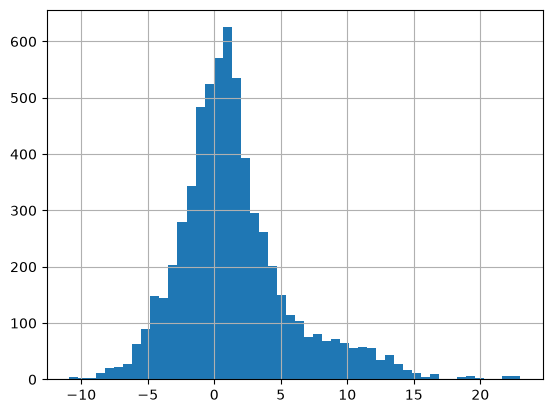

In [28]:
# Let's visualize how this looks like for all interactions  (across all cell types)
lr_res_sepsis = lr_res_sepsis.sort_values("interaction_stat", ascending=False)
lr_res_sepsis['interaction_stat'].hist(bins=50)

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_text : Removed 401 rows containing missing values.


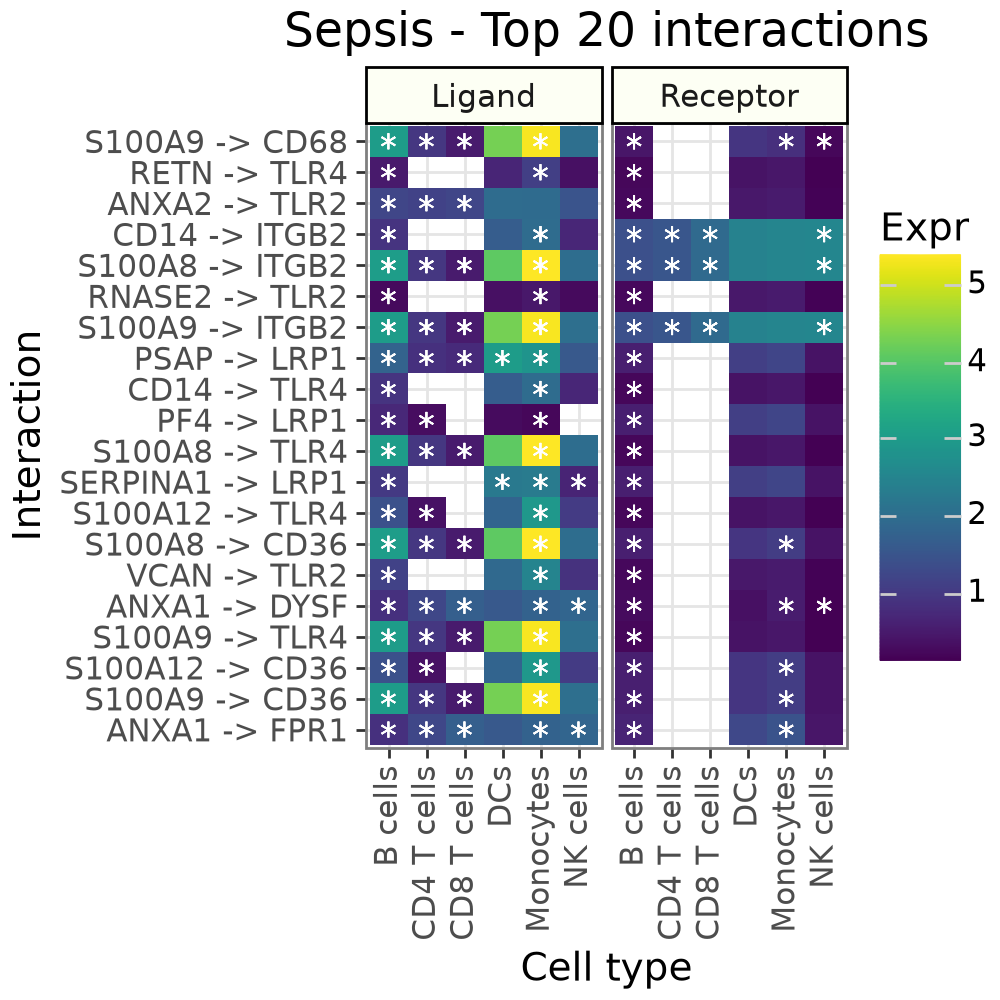

In [30]:
tile_plot = li.pl.tileplot(
    liana_res=lr_res_sepsis,
    fill='expr',
    label='padj',
    label_fun=lambda x: '*' if x < 0.05 else np.nan,
    top_n=20,
    orderby='interaction_stat',
    orderby_ascending=False,
    orderby_absolute=False,
    source_title='Ligand',
    target_title='Receptor',
)

tile_plot + p9.ggtitle(f"{object_sepsis} - Top 20 interactions")

- expression criteria 0.1
- stars = significant (<0.05)
- shows in which cell types ligand gene appears and same for receptor
 
= which cell types can supply the ligand and which can supply the receptor in this selected interaction

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/plotnine/scales/scales.py:48: PlotnineWarning: Scale for 'color' is already present.
Adding another scale for 'color',
which will replace the existing scale.



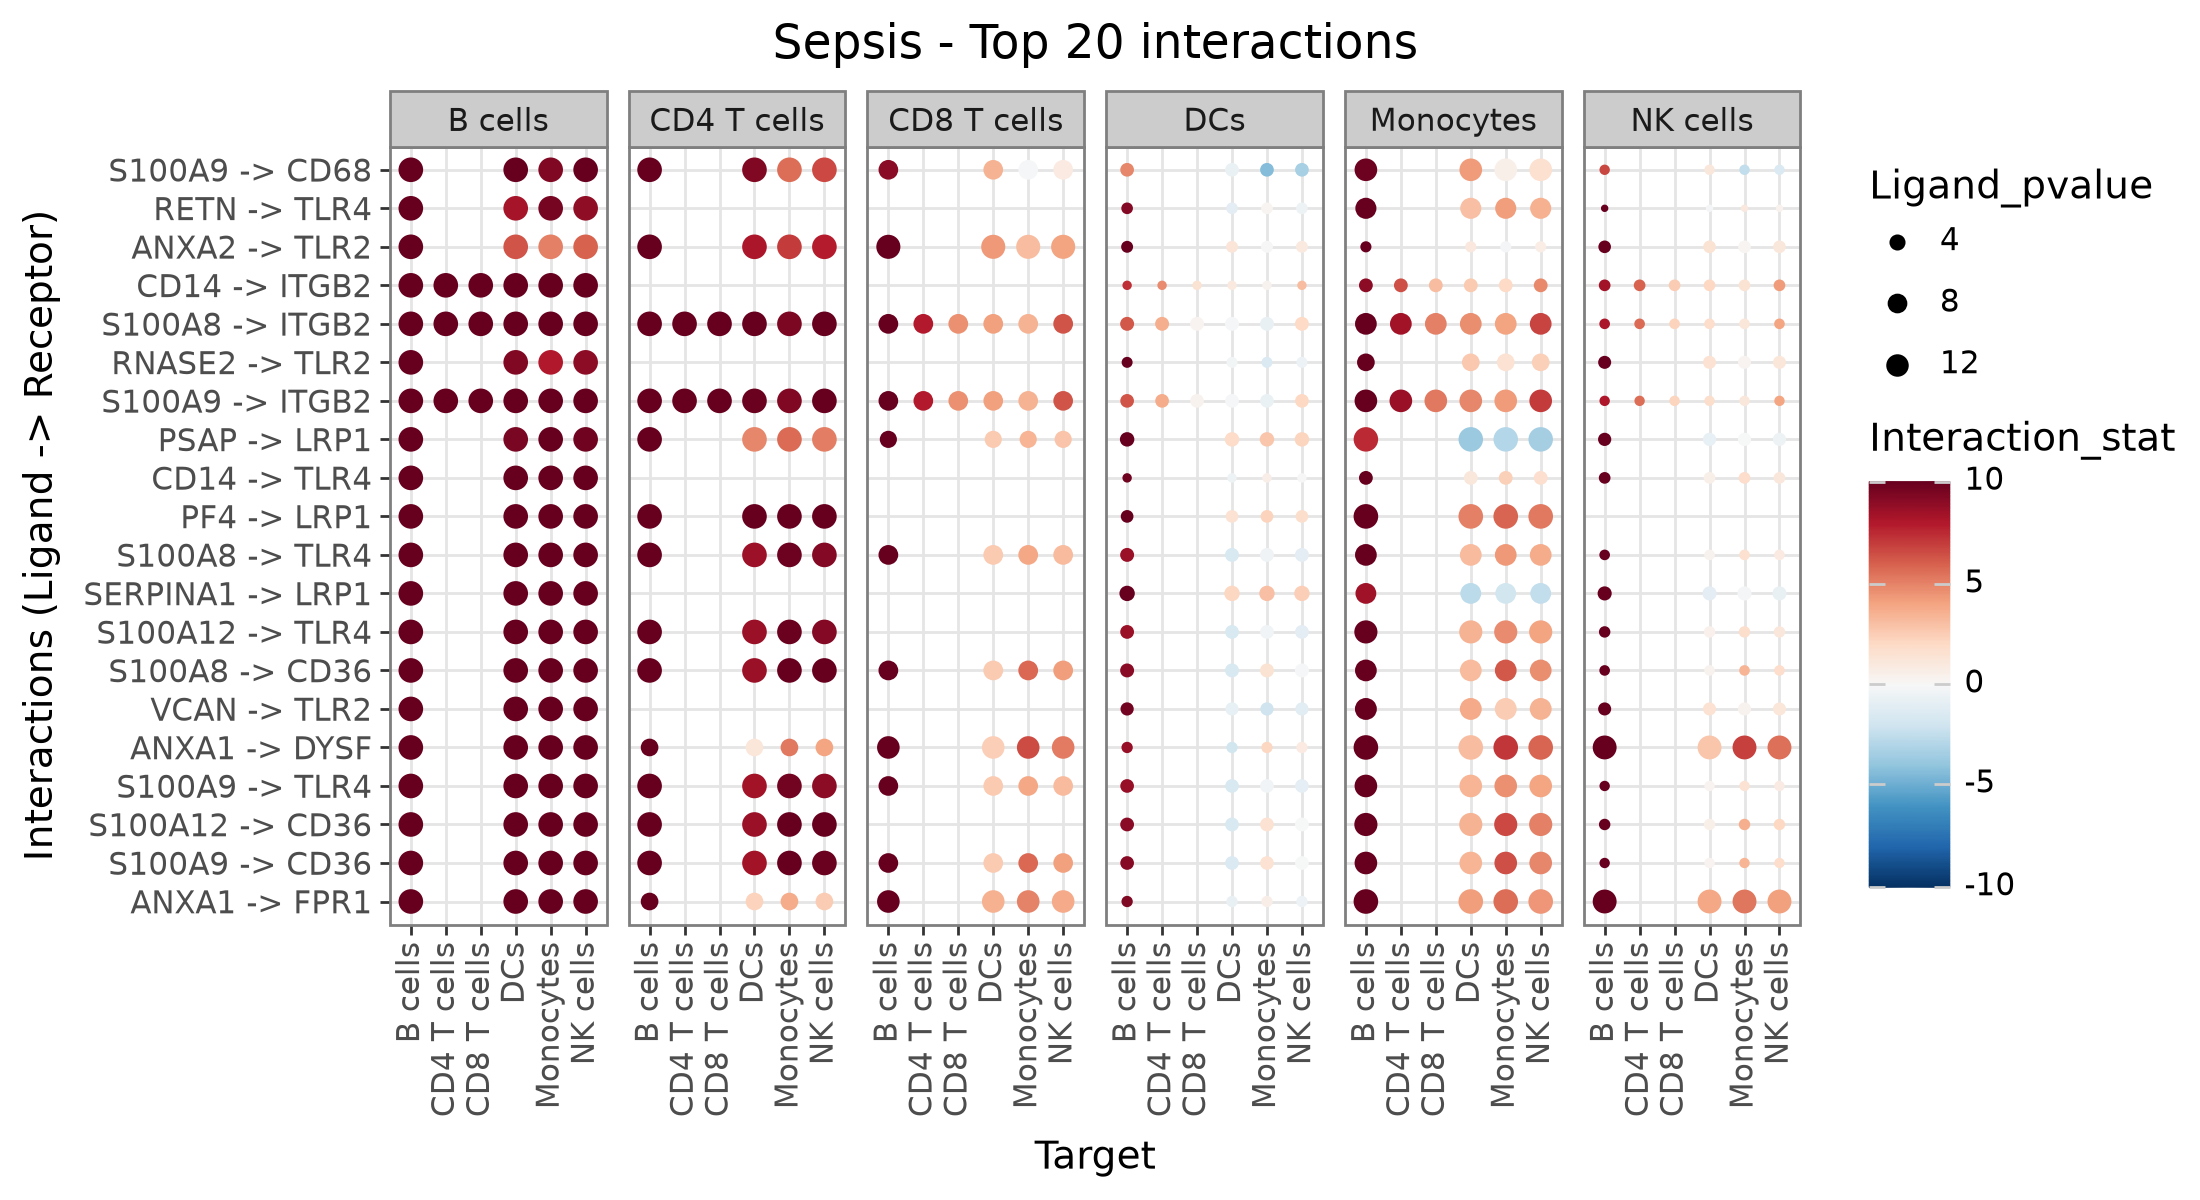

In [32]:
plot = li.pl.dotplot(
    liana_res=lr_res_sepsis,
    colour='interaction_stat',
    size='ligand_pvalue',
    inverse_size=True,
    orderby='interaction_stat',
    orderby_ascending=False,
    orderby_absolute=True,
    top_n=20,
    size_range=(0.5, 4)
)

(
    plot
    + p9.theme_bw(base_size=14)
    + p9.scale_color_cmap('RdBu_r', limits=(-10, 10))
    + p9.ggtitle(f"{object_sepsis} - Top 20 interactions")
    + p9.theme(
        axis_text_x=p9.element_text(angle=90),
        figure_size=(11, 6)
    )
)

How strong is S100A9 → CD68 specifically from sender cell type X to receiver cell type Y?

# Immune Aging

In [34]:
mdata_immuneAging = mu.read("/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/python_objekte/gated_ImmuneAging_with_metadata.h5mu")

object_immuneAging = "Immune Aging"

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/mudata/_core/mudata.py:613: UserWarning: Cannot join columns with the same name because var_names are intersecting.


In [35]:
mdata_immuneAging

MuData object with n_obs × n_vars = 76611 × 35592
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'sample_preservation_method', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'donor_BMI_at_collection', 'tissue_type', 'suspension_enriched_cell_types', 'suspension_type', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'donor_smoking_status', 'disease_ontology_term_id', 'sex_ontology_term_id', 'cmv', 'Gross_annotation', 'tissue_ontology_term_id', 'suspension_derivation_process', 'suspension_depletion_factors', 'suspension_depleted_cell_types', 'suspension_dissociation_reagent', 'suspension_dissociation_time', 'library_id_demultiplexed_tissue', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'percent.mt', 'percent.ribo', 'percent.hb', 'mt_outlier_all', 'is_outlier_RNA', 'is_outlier_protein', 'is_outlier', 'scDblFinder.class', 'scDblFinder.score', 'RNA_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.25', 'RNA.weight', 'ADT_corrected.weight', 'wsnn_res.0.5', 'wsnn_res.0.25', 'celltype_full', 'lineage', 'pla_status', 'celltype', 'Dataset', 'Cohort', 'Condition', 'Sex', 'Age', 'Ethnicity_Race', 'inner_batch_effect', 'patient_ID', 'sample_ID'
  2 modalities
    rna:	76611 × 35465
    adt:	76611 × 127

In [36]:
base_sample_key = "patient_ID"
groupby = "lineage"
condition_key = "pla_status"

In [45]:
mdata_immuneAging.obs[
    ["patient_ID", "sample_ID", "donor_id"]
].drop_duplicates().sort_values("patient_ID")

,patient_ID,sample_ID,donor_id
CGATGTAGTATAGTAG-1_CZI-IA10244331,621B,sample_ID,621B
CTGTTTAAGGTGTGGT-1_CZI-IA10466283-2,637C,sample_ID,637C
CACACTCAGAAACCTA-1_CZI-IA11512686-1,694B,sample_ID,694B
CAGCTAAAGCGTTCCG-1_CZI-IA12953812-3,759B,sample_ID,759B
CAGCGACAGTCTTGCA-1_CZI-IA13073100-1,768B,sample_ID,768B
TGCTACCAGATACACA-1_CZI-IA13003100-9,778C,sample_ID,778C
TACTTACGTCGCATCG-1_CZINY-0104-7,D496,sample_ID,D496
CAGTTCCAGACCACGA-1_CZINY-0055-6,D503,sample_ID,D503
GCAGTTAAGGGCTTGA-1_CZINY-0167-5,D512,sample_ID,D512
CGGACTGGTGGGTATG-1_CZINY-0238-13,D520,sample_ID,D520


We cannot use sample_ID.

In [46]:
adata_immuneAging = mdata_immuneAging["rna"].copy()

cols = ["patient_ID", "lineage", "pla_status"]
adata_immuneAging.obs[cols] = mdata_immuneAging.obs.loc[adata_immuneAging.obs_names, cols]

# merge missing celltypes into Unassigned
adata_immuneAging.obs[groupby] = adata_immuneAging.obs[groupby].fillna("Unassigned")

# missing condition to platelet-free
adata_immuneAging.obs[condition_key] = adata_immuneAging.obs[condition_key].fillna("platelet-free")

# one pseudobulk replicate for every biological sample × PLA state
adata_immuneAging.obs["pb_sample"] = (
    adata_immuneAging.obs[base_sample_key].astype(str)
    + "__"
    + adata_immuneAging.obs[condition_key].astype(str)
)

sample_key = "pb_sample"

In [47]:
print(adata_immuneAging.obs["pb_sample"])

cell_barcode
TGCTACCAGATACACA-1_CZI-IA13003100-9    778C__platelet-free
TTGACTTGTCGCTTCT-1_CZINY-0651-2        D564__platelet-free
GCAGTTAAGGGCTTGA-1_CZINY-0167-5        D512__platelet-free
GCAGCCAAGAAGGTTT-1_CZI-IA13003095-4    778C__platelet-free
GTACTTTAGAAGGGTA-1_CZINY-0524-3        D534__platelet-free
                                              ...         
CTTACCGGTGCAACGA-1_CZINY-0175-13       D512__platelet-free
TAGTGGTCATCTCCCA-1_CZINY-0532-10       D534__platelet-free
TTTGCGCAGTTAGCGG-1_CZINY-0413-12       D529__platelet-free
GAAACTCCAAGTTAAG-1_CZINY-0525-4        D534__platelet-free
GTGGGTCGTGCAGACA-1_CZI-IA13003091-0    778C__platelet-free
Name: pb_sample, Length: 76611, dtype: object


In [66]:
pdata_immuneAging = dc.pp.pseudobulk(
    adata_immuneAging,
    sample_col=sample_key,
    groups_col=groupby,
    layer=None,
    mode="sum"
)

pdata_immuneAging

AnnData object with n_obs × n_vars = 350 × 35465
    obs: 'pb_sample', 'lineage', 'patient_ID', 'pla_status', 'psbulk_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [50]:
for min_cells in [1, 3, 5, 10]:
    
    keep = (
        (pdata_immuneAging.obs["psbulk_cells"] >= min_cells) &
        (pdata_immuneAging.obs["psbulk_counts"] >= 1000) &
        (pdata_immuneAging.obs["pla_status"] == "PLA")
    )
    
    print(f"\nmin_cells = {min_cells}")
    print(
        pdata_immuneAging.obs.loc[keep]
        .groupby("lineage", observed=True)
        .size()
    )


min_cells = 1
lineage
B cells         7
CD4 T cells    10
CD8 T cells     7
Monocytes      16
NK cells       13
Neutrophils    12
dtype: int64

min_cells = 3
lineage
B cells         4
CD4 T cells     6
CD8 T cells     2
Monocytes      16
NK cells        7
Neutrophils     5
dtype: int64

min_cells = 5
lineage
B cells         4
CD4 T cells     4
CD8 T cells     2
Monocytes      14
NK cells        5
Neutrophils     3
dtype: int64

min_cells = 10
lineage
B cells         2
CD4 T cells     2
CD8 T cells     2
Monocytes      10
NK cells        1
Neutrophils     1
dtype: int64


In [67]:
# filter samples based on number of cells and counts
dc.pp.filter_samples(pdata_immuneAging, min_cells = 3, min_counts=1000)

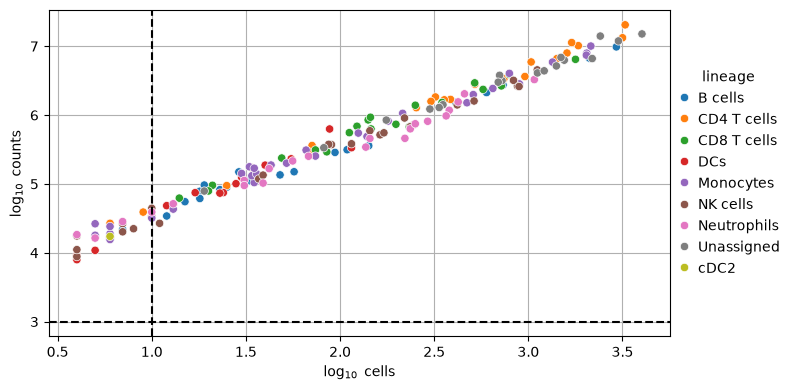

In [68]:
dc.pl.filter_samples(
    pdata_immuneAging,
    groupby=groupby,
    figsize=(8, 4)
)

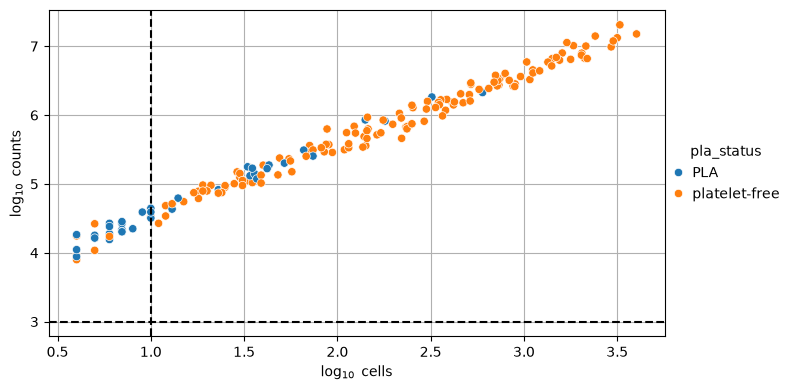

In [69]:
dc.pl.filter_samples(
    pdata_immuneAging,
    groupby=condition_key,
    figsize=(8, 4)
)

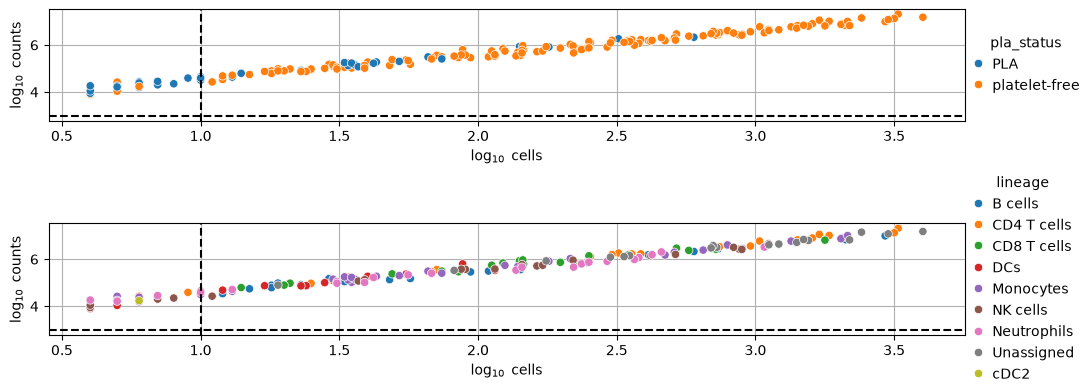

In [70]:
dc.pl.filter_samples(pdata_immuneAging, groupby=[condition_key, groupby], figsize=(11, 4))

In [71]:
pdata_immuneAging.obs.groupby(groupby)["psbulk_cells"].describe()

,count,mean,std,min,25%,50%,75%,max
lineage,,,,,,,,
B cells,21.0,353.571429,759.849299,5.0,17.00,32.0,141.00,2933.0
CD4 T cells,24.0,753.583333,961.202956,4.0,30.75,338.5,1129.50,3267.0
CD8 T cells,20.0,316.200000,415.637950,13.0,81.25,144.5,389.75,1779.0
DCs,15.0,29.733333,32.558665,3.0,7.00,22.0,34.00,114.0
Monocytes,31.0,387.451613,646.144351,4.0,20.50,51.0,490.00,2147.0
NK cells,25.0,249.200000,332.384441,3.0,9.00,114.0,246.00,1114.0
Neutrophils,22.0,194.045455,248.266845,3.0,30.00,101.5,280.75,1075.0
Unassigned,18.0,1209.500000,1100.407425,18.0,339.00,920.5,1535.75,4013.0
cDC2,1.0,5.000000,NaN,5.0,5.00,5.0,5.00,5.0


In [72]:
tmp = (
    pdata_immuneAging.obs
    .groupby(["patient_ID", "lineage", "pla_status"], observed=True)
    .size()
    .unstack("pla_status", fill_value=0)
)

tmp

pla_status              PLA  platelet-free
patient_ID lineage                        
621B       B cells        0              1
           CD4 T cells    0              1
           CD8 T cells    0              1
           NK cells       0              1
           Unassigned     0              1
...                     ...            ...
D570       DCs            0              1
           Monocytes      1              1
           NK cells       0              1
           Neutrophils    0              1
           Unassigned     0              1

[139 rows x 2 columns]

In [73]:
for ct in pdata_immuneAging.obs[groupby].unique():

    tmp = pdata_immuneAging.obs[pdata_immuneAging.obs[groupby] == ct]

    tab = pd.crosstab(
        tmp["patient_ID"],
        tmp["pla_status"]
    )

    complete = (
        (tab.get("PLA", 0) > 0) &
        (tab.get("platelet-free", 0) > 0)
    )

    print(
        ct,
        "| complete pairs:", complete.sum(),
        "| patients:", len(tab),
        "| PLA:", (tmp["pla_status"] == "PLA").sum(),
        "| platelet-free:", (tmp["pla_status"] == "platelet-free").sum()
    )

B cells | complete pairs: 4 | patients: 17 | PLA: 4 | platelet-free: 17
CD4 T cells | complete pairs: 6 | patients: 18 | PLA: 6 | platelet-free: 18
CD8 T cells | complete pairs: 2 | patients: 18 | PLA: 2 | platelet-free: 18
DCs | complete pairs: 0 | patients: 15 | PLA: 0 | platelet-free: 15
Monocytes | complete pairs: 14 | patients: 17 | PLA: 16 | platelet-free: 15
NK cells | complete pairs: 7 | patients: 18 | PLA: 7 | platelet-free: 18
Neutrophils | complete pairs: 5 | patients: 17 | PLA: 5 | platelet-free: 17
Unassigned | complete pairs: 0 | patients: 18 | PLA: 0 | platelet-free: 18
cDC2 | complete pairs: 0 | patients: 1 | PLA: 0 | platelet-free: 1


In [74]:
dea_results_immuneAging = {}
quiet = True
min_complete_pairs = 4

for cell_group in pdata_immuneAging.obs[groupby].unique():

    ctdata = pdata_immuneAging[pdata_immuneAging.obs[groupby] == cell_group].copy()

    # define condition categories
    ctdata.obs[condition_key] = (
        ctdata.obs[condition_key]
        .astype("category")
        .cat.set_categories(
            ["platelet-free", "PLA"],
            ordered=True
        )
    )

    # identify complete pairs
    pair_table = pd.crosstab(
        ctdata.obs["patient_ID"],
        ctdata.obs[condition_key]
    )

    complete = (
        (pair_table.get("PLA", 0) > 0) &
        (pair_table.get("platelet-free", 0) > 0)
    )

    complete_patients = pair_table.index[complete]
    n_complete_pairs = len(complete_patients)

    print(
        f"{cell_group} | "
        f"complete pairs: {n_complete_pairs}"
    )

    if n_complete_pairs < min_complete_pairs:
        print(
            f"Skipping DE for {cell_group}: "
            f"only {n_complete_pairs} complete patient pairs"
        )
        continue

    # keep only sufficient
    ctdata = ctdata[
        ctdata.obs["patient_ID"].isin(complete_patients)
    ].copy()

    # condition reference level
    ctdata.obs[condition_key] = (
        ctdata.obs[condition_key]
        .astype("category")
        .cat.set_categories(
            ["platelet-free", "PLA"],
            ordered=True
        )
    )

    print(
        f"Using {ctdata.n_obs} pseudobulks "
        f"from {n_complete_pairs} paired patients"
    )

    print(
        ctdata.obs[condition_key].value_counts()
    )

   # filter genes after selecting samples
    dc.pp.filter_by_expr(
        ctdata,
        group=condition_key,
        min_count=5,
        min_total_count=10
    )

    print(f"Genes after filtering: {ctdata.n_vars}")

   # paired DESeq2
    dds = DeseqDataSet(
        adata=ctdata,
        design="~ patient_ID + pla_status",
        refit_cooks=True,
        quiet=quiet
    )

    dds.deseq2()

    # PLA versus platelet-free
    stat_res = DeseqStats(
        dds,
        contrast=[
            condition_key,
            "PLA",
            "platelet-free"
        ],
        quiet=quiet
    )

    stat_res.summary()

    # shrink LFC
    stat_res.lfc_shrink(
        coeff="pla_status[T.PLA]"
    )

    dea_results_immuneAging[cell_group] = stat_res.results_df

B cells | complete pairs: 4
Using 8 pseudobulks from 4 paired patients
pla_status
platelet-free    4
PLA              4
Name: count, dtype: int64
Genes after filtering: 8918


/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/utils

CD4 T cells | complete pairs: 6
Using 12 pseudobulks from 6 paired patients
pla_status
platelet-free    6
PLA              6
Name: count, dtype: int64
Genes after filtering: 5634


/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  co

CD8 T cells | complete pairs: 2
Skipping DE for CD8 T cells: only 2 complete patient pairs
DCs | complete pairs: 0
Skipping DE for DCs: only 0 complete patient pairs
Monocytes | complete pairs: 14
Using 28 pseudobulks from 14 paired patients
pla_status
platelet-free    14
PLA              14
Name: count, dtype: int64
Genes after filtering: 5355
NK cells | complete pairs: 7
Using 14 pseudobulks from 7 paired patients
pla_status
platelet-free    7
PLA              7
Name: count, dtype: int64
Genes after filtering: 2391


/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.


Neutrophils | complete pairs: 5
Using 10 pseudobulks from 5 paired patients
pla_status
platelet-free    5
PLA              5
Name: count, dtype: int64
Genes after filtering: 3383


/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.


Unassigned | complete pairs: 0
Skipping DE for Unassigned: only 0 complete patient pairs
cDC2 | complete pairs: 0
Skipping DE for cDC2: only 0 complete patient pairs


Very small amount of reliable, independent data. Thus unreliable results. Need to treat with caution. Monocytes seem stable.

PLA cells are also not fairly distributed:

In [75]:
pla_cells = adata_immuneAging[adata_immuneAging.obs["pla_status"] == "PLA"]

pd.crosstab(
    pla_cells.obs["patient_ID"],
    pla_cells.obs["lineage"]
)

lineage,B cells,CD4 T cells,CD8 T cells,Monocytes,NK cells,Neutrophils
patient_ID,,,,,,
621B,0,0,1,0,0,0
637C,2,5,13,5,9,6
694B,5,1,1,4,7,1
759B,599,320,140,33,36,41
768B,6,8,2,65,2,4
778C,22,12,0,179,3,9
D496,0,0,0,5,0,0
D512,1,4,2,42,6,2
D520,0,0,0,5,1,1


In [76]:
# concat results across cell types
dea_df_immuneAging = pd.concat(
    dea_results_immuneAging,
    names=[groupby, "gene"]
)

dea_df_immuneAging = dea_df_immuneAging.reset_index(level=0)

dea_df_immuneAging.head()

,lineage,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,,
LINC01409,B cells,5.933010,-1.207611e-06,0.001313,-0.660077,0.509204,0.999827
LINC01128,B cells,9.129372,1.089372e-06,0.001785,0.635180,0.525311,0.999827
NOC2L,B cells,16.527083,1.818473e-06,0.001670,-0.482004,0.629803,0.999827
HES4,B cells,4.448121,4.397367e-07,0.001716,0.677364,0.498175,0.999827
ISG15,B cells,7.355724,2.255831e-07,0.001644,0.284499,0.776028,0.999827


In [77]:
# PyDeseq Seems to intrdoce NAs for some p-values
# NOTE: there sometimes some NaN being introduced, best to double check that
len(dea_df_immuneAging[dea_df_immuneAging.isna().any(axis=1)])
dea_df_immuneAging.isna().sum().sort_values(ascending=False)

lineage           0
baseMean          0
log2FoldChange    0
lfcSE             0
stat              0
pvalue            0
padj              0
dtype: int64

In [78]:
print(
    f"{dea_df_immuneAging.isna().any(axis=1).sum()} / {len(dea_df_immuneAging)} "
    f"({dea_df_immuneAging.isna().any(axis=1).mean():.2%})"
)

0 / 25681 (0.00%)


In [79]:
adata_lr_immuneAging = mdata_immuneAging["rna"].copy()

# copy required metadata into RNA AnnData
cols = [condition_key, groupby]
adata_lr_immuneAging.obs[cols] = mdata_immuneAging.obs.loc[adata_lr_immuneAging.obs_names, cols]

# keep only PLA cells
adata_lr_immuneAging = adata_lr_immuneAging[
    adata_lr_immuneAging.obs[condition_key] == "PLA"
].copy()

# normalize RNA expression for LIANA expression/proportion calculations
sc.pp.normalize_total(adata_lr_immuneAging, target_sum=1e4)
sc.pp.log1p(adata_lr_immuneAging)

In [80]:
lr_res_immuneAging = li.multi.df_to_lr(
    adata_lr_immuneAging,
    dea_df=dea_df_immuneAging,
    resource_name="consensus",
    expr_prop=0.1,
    groupby=groupby,
    stat_keys=["stat", "pvalue", "padj"],
    use_raw=False,
    complex_col="stat",
    verbose=True,
    return_all_lrs=False,
)

lr_res_immuneAging = lr_res_immuneAging.sort_values(
    "interaction_stat",
    ascending=False,
    key=abs
)

lr_res_immuneAging.head()

Using resource `consensus`.
Using `.X`!
16119 features of mat are empty, they will be removed.
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:164: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
Features in adata and dea_df are mismatched.
0.73 of entities in the resource are missing from the data.


,ligand,receptor,ligand_complex,receptor_complex,source,ligand_stat,ligand_pvalue,ligand_padj,ligand_expr,ligand_props,...,receptor_pvalue,receptor_padj,receptor_expr,receptor_props,interaction_stat,interaction_pvalue,interaction_padj,interaction_expr,interaction_props,interaction
2287,IL1B,IL1R2,IL1B,IL1R2_IL1RAP,Neutrophils,6.182408,6.313127e-10,6.281562e-08,0.649841,0.328767,...,8.695732e-09,5.550502e-07,2.250962,0.863014,5.968397,4.663522e-09,3.089329e-07,1.450402,0.595890,IL1B^IL1R2_IL1RAP
2294,S100A9,CD68,S100A9,CD68,Neutrophils,6.453349,1.094051e-10,1.821577e-08,5.147666,0.958904,...,1.283592e-07,4.991256e-06,1.345142,0.739726,5.867261,6.423432e-08,2.504736e-06,3.246403,0.849315,S100A9^CD68
2291,S100A8,CD68,S100A8,CD68,Neutrophils,6.361772,1.994388e-10,2.595005e-08,5.325191,0.972603,...,1.283592e-07,4.991256e-06,1.345142,0.739726,5.821473,6.427934e-08,2.508603e-06,3.335166,0.856164,S100A8^CD68
2316,SERPINA1,LRP1,SERPINA1,LRP1,Neutrophils,5.728602,1.012617e-08,5.906351e-07,1.617205,0.808219,...,6.514120e-08,2.825291e-06,0.874434,0.534247,5.566342,3.763369e-08,1.707963e-06,1.245819,0.671233,SERPINA1^LRP1
2293,S100A9,CD36,S100A9,CD36,Neutrophils,6.453349,1.094051e-10,1.821577e-08,5.147666,0.958904,...,7.681560e-06,1.310007e-04,0.388301,0.287671,5.463611,3.840834e-06,6.550944e-05,2.767983,0.623288,S100A9^CD36


<Axes: >

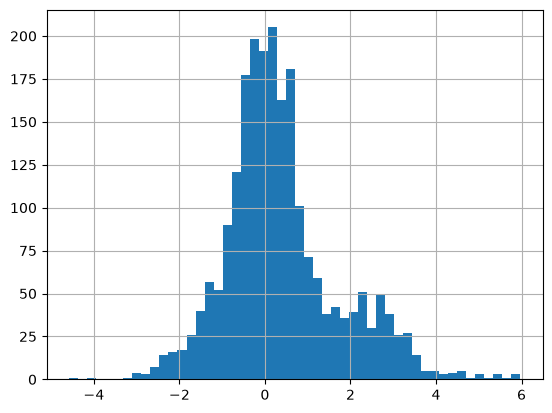

In [81]:
# Let's visualize how this looks like for all interactions  (across all cell types)
lr_res_immuneAging = lr_res_immuneAging.sort_values("interaction_stat", ascending=False)
lr_res_immuneAging['interaction_stat'].hist(bins=50)

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_text : Removed 170 rows containing missing values.


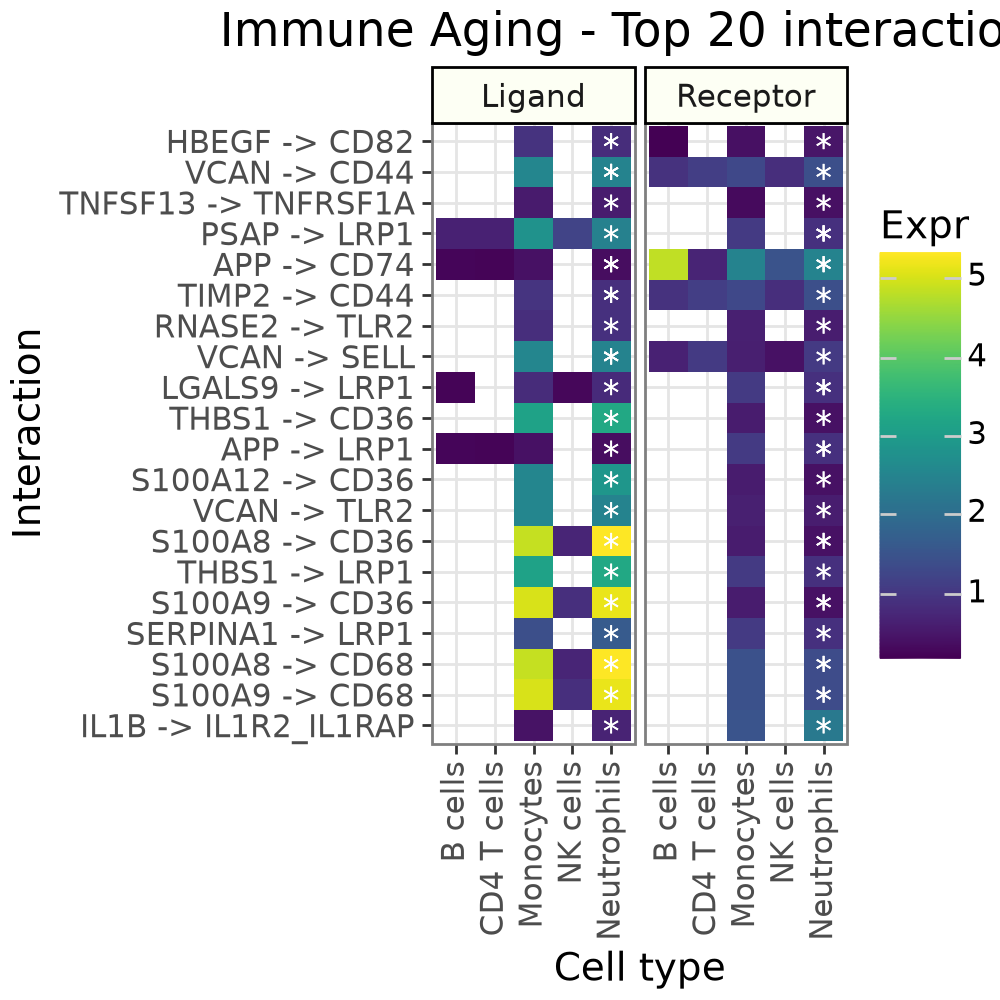

In [83]:
tile_plot = li.pl.tileplot(
    liana_res=lr_res_immuneAging,
    fill='expr',
    label='padj',
    label_fun=lambda x: '*' if x < 0.05 else np.nan,
    top_n=20,
    orderby='interaction_stat',
    orderby_ascending=False,
    orderby_absolute=False,
    source_title='Ligand',
    target_title='Receptor',
)

tile_plot + p9.ggtitle(f"{object_immuneAging} - Top 20 interactions")

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/plotnine/scales/scales.py:48: PlotnineWarning: Scale for 'color' is already present.
Adding another scale for 'color',
which will replace the existing scale.



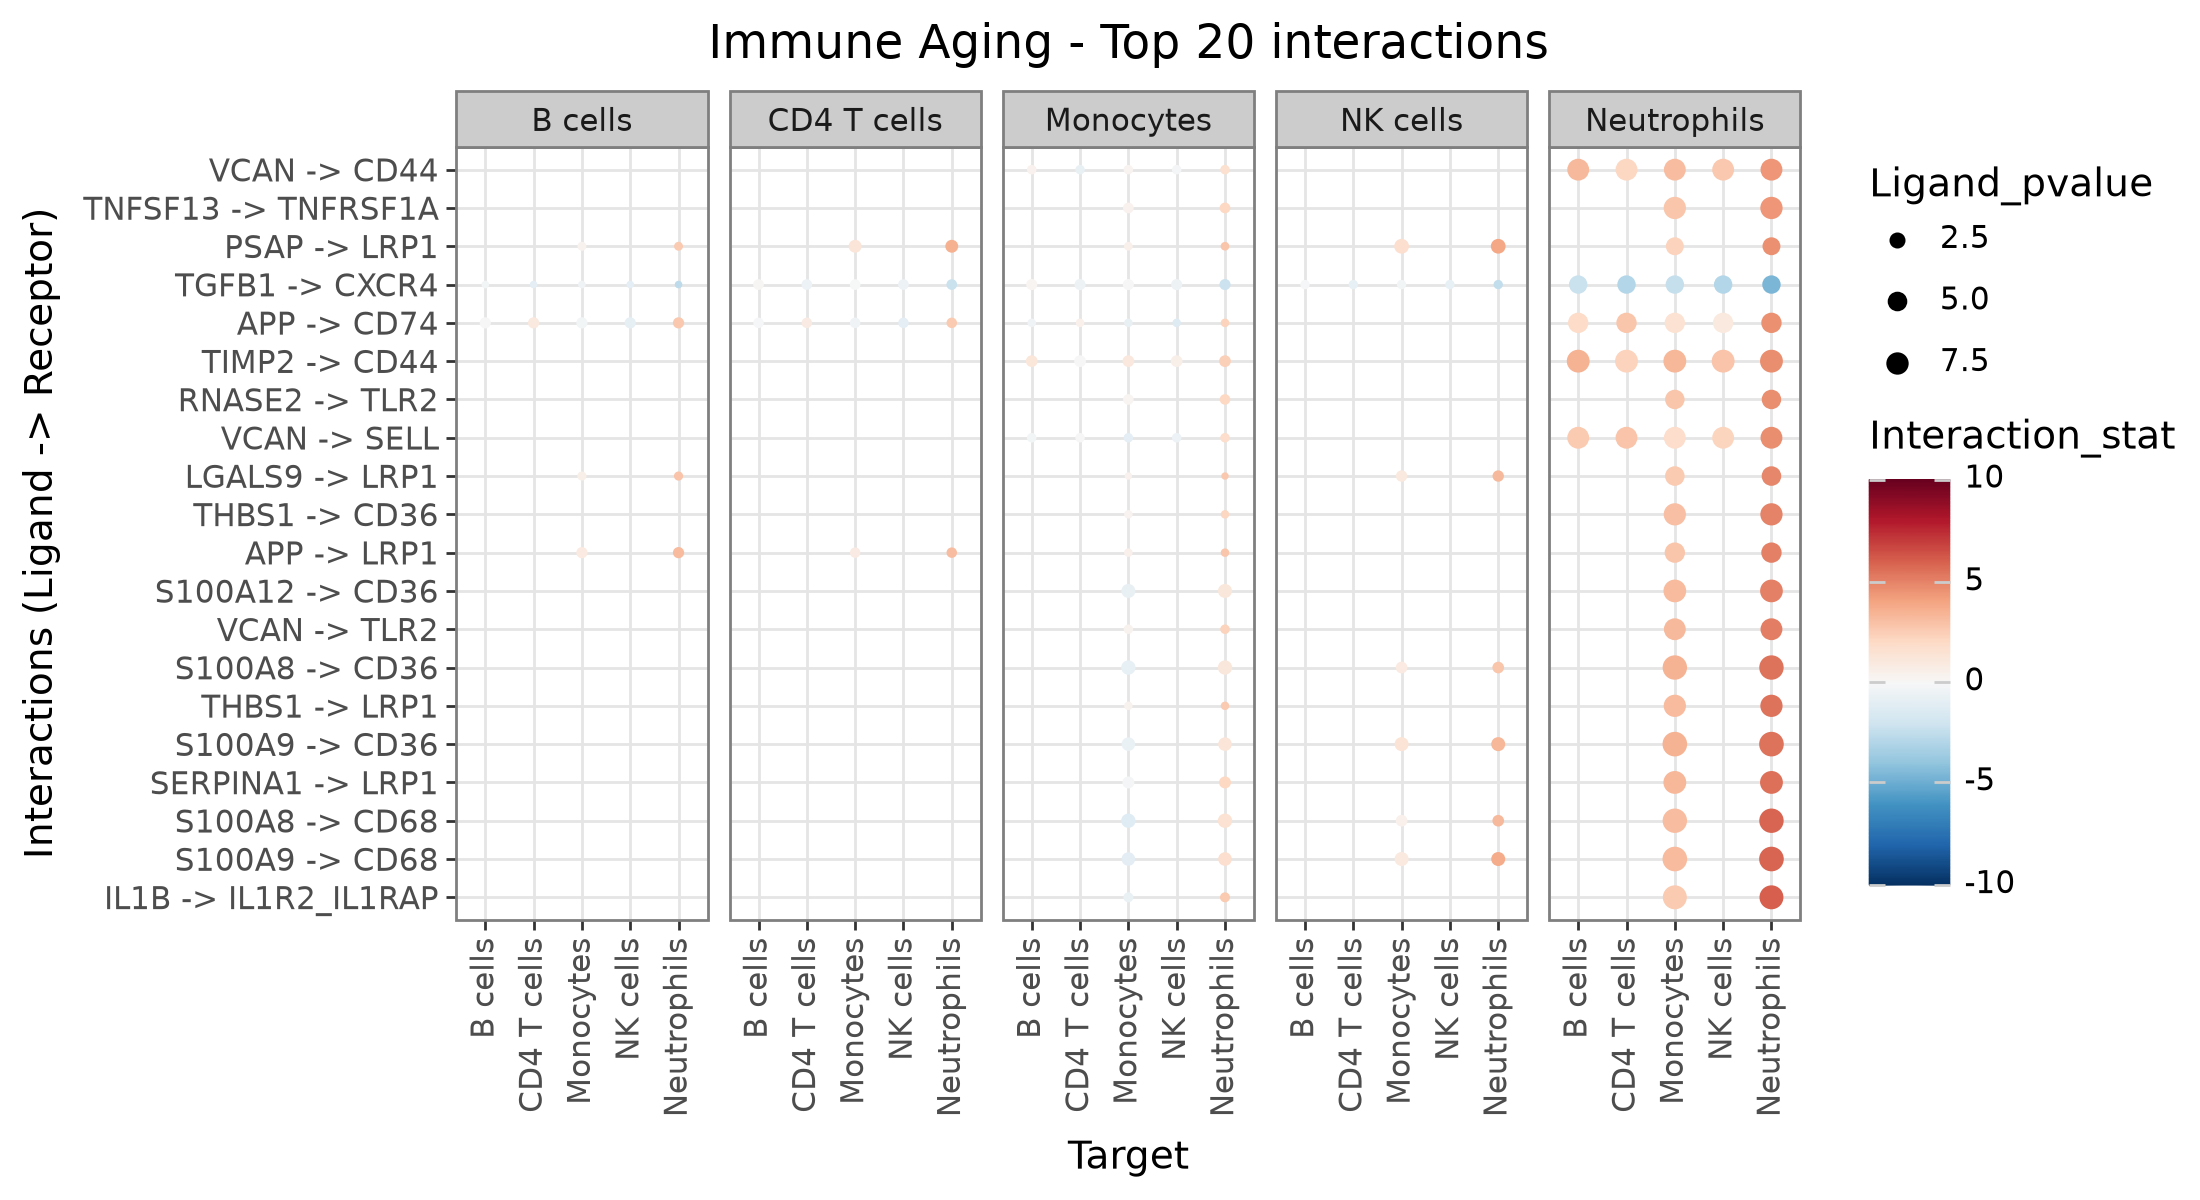

In [84]:
plot = li.pl.dotplot(
    liana_res=lr_res_immuneAging,
    colour='interaction_stat',
    size='ligand_pvalue',
    inverse_size=True,
    orderby='interaction_stat',
    orderby_ascending=False,
    orderby_absolute=True,
    top_n=20,
    size_range=(0.5, 4)
)

(
    plot
    + p9.theme_bw(base_size=14)
    + p9.scale_color_cmap('RdBu_r', limits=(-10, 10))
    + p9.ggtitle(f"{object_immuneAging} - Top 20 interactions")
    + p9.theme(
        axis_text_x=p9.element_text(angle=90),
        figure_size=(11, 6)
    )
)

Despite greater statistical power for monocytes, the strongest differential communication signal is associated with neutrophil-derived interactions.

# Skin

In [85]:
mdata_skin = mu.read("/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/python_objekte/gated_skin_with_metadata.h5mu")

object_skin = "Skin"

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/mudata/_core/mudata.py:613: UserWarning: Cannot join columns with the same name because var_names are intersecting.


In [86]:
mdata_skin

MuData object with n_obs × n_vars = 139459 × 33976
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'sample', 'cell_barcodes', 'runID_folder', 'CellName', 'RunID', 'Run', 'Subject', 'Status', 'DemuxletDropletType', 'IncludedInStudy', 'CellType', 'donorID', 'percent.mt', 'percent.ribo', 'percent.hb', 'mt_outlier_all', 'is_outlier_RNA', 'is_outlier_protein', 'is_outlier', 'RNA_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.25', 'RNA.weight', 'ADT.weight', 'leiden_0.8_totalVI', 'leiden_0.25_totalVI', 'celltype_full', 'lineage', 'pla_status', 'celltype', 'Dataset', 'Cohort', 'Condition', 'Sex', 'Age', 'Ethnicity_Race', 'inner_batch_effect', 'patient_ID', 'sample_ID'
  2 modalities
    rna:	139459 × 33694
    adt:	139459 × 282

In [87]:
mdata_skin.obs[["patient_ID", "sample", "sample_ID"]]

,patient_ID,sample,sample_ID
PBMC-02-1_AAACCCATCAGCCTTC-1,HC11,PBMC-02-1,PBMC-02-1
PBMC-02-1_AAACCCATCCTATTTG-1,HC16,PBMC-02-1,PBMC-02-1
PBMC-02-1_AAACCCATCGGCTGGT-1,PSX11,PBMC-02-1,PBMC-02-1
PBMC-02-1_AAACCCATCGTGGACC-1,HC11,PBMC-02-1,PBMC-02-1
PBMC-02-1_AAACGAAAGTACAGAT-1,HC15,PBMC-02-1,PBMC-02-1
...,...,...,...
PBMC-07-3_TTTGGTTCATGGAACG-1,PSA01,PBMC-07-3,PBMC-07-3
PBMC-07-3_TTTGGTTGTACAATAG-1,PSA11,PBMC-07-3,PBMC-07-3
PBMC-07-3_TTTGTTGAGAACCCGA-1,PSX06,PBMC-07-3,PBMC-07-3
PBMC-07-3_TTTGTTGTCCAGCCTT-1,unknown,PBMC-07-3,PBMC-07-3


Same sample associated with different patients.

In [96]:
# How many patient IDs occur within each sample?
mdata_skin.obs.groupby("sample")["patient_ID"].nunique().sort_values(ascending=False)

sample
PBMC-02-1    21
PBMC-02-3    21
PBMC-02-4    21
PBMC-05-4    21
PBMC-05-3    21
PBMC-05-2    21
PBMC-05-1    21
PBMC-04-4    20
PBMC-04-3    20
PBMC-04-2    20
PBMC-04-1    20
PBMC-06-2    20
PBMC-06-3    20
PBMC-06-4    20
PBMC-07-3    17
PBMC-03-2    16
PBMC-03-3    16
PBMC-03-1    14
PBMC-03-4    14
Name: patient_ID, dtype: int64

Each PBMC sample is of many patients. Pseudobulking via patient_ID

In [92]:
base_sample_key = "sample"
groupby = "lineage"
condition_key = "pla_status"

In [99]:
adata_skin = mdata_skin["rna"].copy()

cols = ["sample", "patient_ID", "lineage", "pla_status"]
adata_skin.obs[cols] = mdata_skin.obs.loc[adata_skin.obs_names, cols]

# merge missing celltypes into Unassigned
adata_skin.obs[groupby] = adata_skin.obs[groupby].fillna("Unassigned")

# missing condition to platelet-free
adata_skin.obs[condition_key] = adata_skin.obs[condition_key].fillna("platelet-free")

# one pseudobulk replicate for every biological sample × PLA state
adata_skin.obs["pb_sample"] = (
    adata_skin.obs["patient_ID"].astype(str)
    + "__"
    + adata_skin.obs[condition_key].astype(str)
)

sample_key = "pb_sample"

In [100]:
print(adata_skin.obs["pb_sample"])

cell_barcode
PBMC-02-1_AAACCCATCAGCCTTC-1       HC11__platelet-free
PBMC-02-1_AAACCCATCCTATTTG-1                 HC16__PLA
PBMC-02-1_AAACCCATCGGCTGGT-1      PSX11__platelet-free
PBMC-02-1_AAACCCATCGTGGACC-1       HC11__platelet-free
PBMC-02-1_AAACGAAAGTACAGAT-1       HC15__platelet-free
                                         ...          
PBMC-07-3_TTTGGTTCATGGAACG-1      PSA01__platelet-free
PBMC-07-3_TTTGGTTGTACAATAG-1      PSA11__platelet-free
PBMC-07-3_TTTGTTGAGAACCCGA-1      PSX06__platelet-free
PBMC-07-3_TTTGTTGTCCAGCCTT-1    unknown__platelet-free
PBMC-07-3_TTTGTTGTCTGGAAGG-1      PSO10__platelet-free
Name: pb_sample, Length: 139459, dtype: object


In [101]:
pdata_skin = dc.pp.pseudobulk(
    adata_skin,
    sample_col=sample_key,
    groups_col=groupby,
    layer=None,
    mode="sum"
)

pdata_skin

AnnData object with n_obs × n_vars = 1521 × 33694
    obs: 'pb_sample', 'lineage', 'patient_ID', 'pla_status', 'psbulk_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [102]:
for min_cells in [1, 3, 5, 10]:
    
    keep = (
        (pdata_skin.obs["psbulk_cells"] >= min_cells) &
        (pdata_skin.obs["psbulk_counts"] >= 1000) &
        (pdata_skin.obs["pla_status"] == "PLA")
    )
    
    print(f"\nmin_cells = {min_cells}")
    print(
        pdata_skin.obs.loc[keep]
        .groupby("lineage", observed=True)
        .size()
    )


min_cells = 1
lineage
B cells           33
CD4 T cells       56
CD8 T cells       46
DCs               23
Monocytes         73
NK cells          28
PLA neutrohils    16
dtype: int64

min_cells = 3
lineage
B cells        15
CD4 T cells    29
CD8 T cells    21
DCs             3
Monocytes      53
NK cells       13
dtype: int64

min_cells = 5
lineage
B cells         6
CD4 T cells    19
CD8 T cells    15
DCs             2
Monocytes      45
NK cells        4
dtype: int64

min_cells = 10
lineage
B cells         1
CD4 T cells    10
CD8 T cells     8
Monocytes      33
NK cells        2
dtype: int64


In [103]:
# filter samples based on number of cells and counts
dc.pp.filter_samples(pdata_skin, min_cells = 3, min_counts=1000)

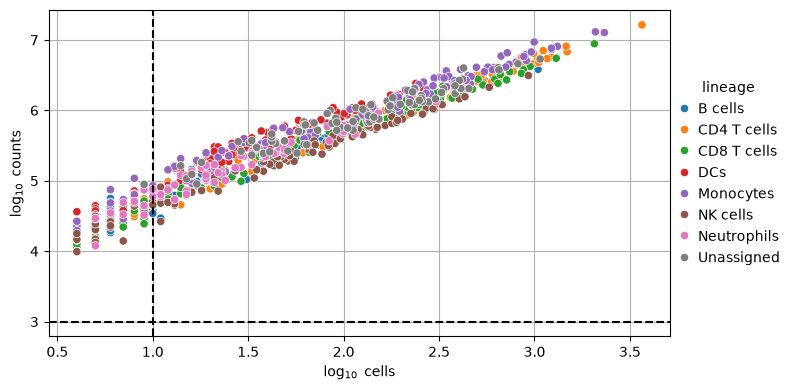

In [104]:
dc.pl.filter_samples(
    pdata_skin,
    groupby=groupby,
    figsize=(8, 4)
)

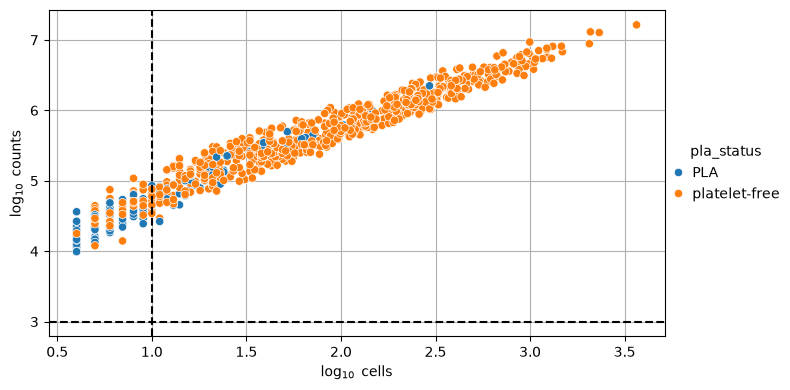

In [106]:
dc.pl.filter_samples(
    pdata_skin,
    groupby=condition_key,
    figsize=(8, 4)
)

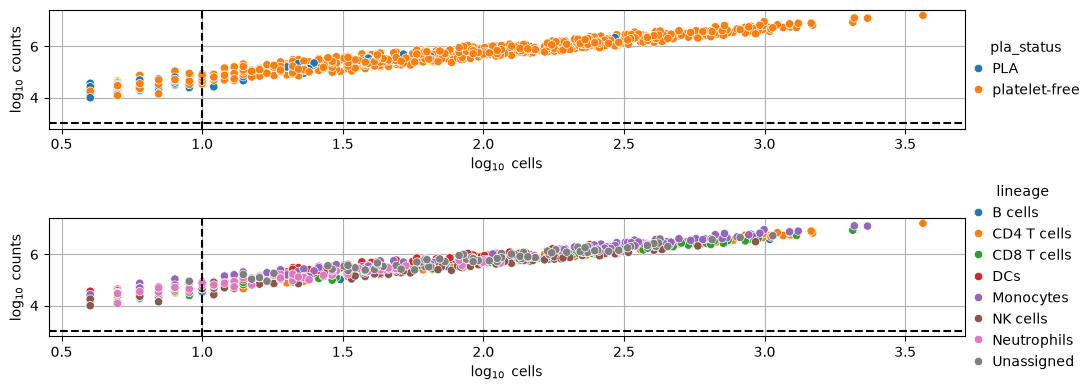

In [107]:
dc.pl.filter_samples(pdata_skin, groupby=[condition_key, groupby], figsize=(11, 4))

In [108]:
pdata_skin.obs.groupby(groupby)["psbulk_cells"].describe()

,count,mean,std,min,25%,50%,75%,max
lineage,,,,,,,,
B cells,100.0,102.720000,142.098350,3.0,10.00,57.0,127.00,1043.0
CD4 T cells,115.0,340.973913,470.041440,3.0,20.50,230.0,456.00,3656.0
CD8 T cells,106.0,209.962264,301.466193,3.0,14.50,99.5,300.75,2058.0
DCs,87.0,52.425287,53.604632,3.0,18.50,31.0,71.50,258.0
Monocytes,140.0,248.328571,370.022349,3.0,15.00,88.0,344.25,2322.0
NK cells,97.0,99.484536,134.738490,3.0,12.00,54.0,133.00,928.0
Neutrophils,70.0,43.157143,53.011247,4.0,12.25,22.0,46.50,304.0
Unassigned,87.0,178.264368,183.136781,8.0,56.50,125.0,238.50,1069.0


In [109]:
tmp = (
    pdata_skin.obs
    .groupby(["patient_ID", "lineage", "pla_status"], observed=True)
    .size()
    .unstack("pla_status", fill_value=0)
)

tmp

pla_status              PLA  platelet-free
patient_ID lineage                        
AS02       B cells        0              1
           CD4 T cells    0              1
           CD8 T cells    0              1
           DCs            0              1
           Monocytes      1              1
...                     ...            ...
unknown    DCs            0              1
           Monocytes      1              1
           NK cells       1              1
           Neutrophils    0              1
           Unassigned     0              1

[668 rows x 2 columns]

In [110]:
for ct in pdata_skin.obs[groupby].unique():

    tmp = pdata_skin.obs[pdata_skin.obs[groupby] == ct]

    tab = pd.crosstab(
        tmp["patient_ID"],
        tmp["pla_status"]
    )

    complete = (
        (tab.get("PLA", 0) > 0) &
        (tab.get("platelet-free", 0) > 0)
    )

    print(
        ct,
        "| complete pairs:", complete.sum(),
        "| patients:", len(tab),
        "| PLA:", (tmp["pla_status"] == "PLA").sum(),
        "| platelet-free:", (tmp["pla_status"] == "platelet-free").sum()
    )

B cells | complete pairs: 15 | patients: 85 | PLA: 15 | platelet-free: 85
CD4 T cells | complete pairs: 29 | patients: 86 | PLA: 29 | platelet-free: 86
CD8 T cells | complete pairs: 21 | patients: 85 | PLA: 21 | platelet-free: 85
DCs | complete pairs: 3 | patients: 84 | PLA: 3 | platelet-free: 84
Monocytes | complete pairs: 53 | patients: 87 | PLA: 53 | platelet-free: 87
NK cells | complete pairs: 13 | patients: 84 | PLA: 13 | platelet-free: 84
Neutrophils | complete pairs: 0 | patients: 70 | PLA: 0 | platelet-free: 70
Unassigned | complete pairs: 0 | patients: 87 | PLA: 0 | platelet-free: 87


In [111]:
dea_results_skin = {}
quiet = True
min_complete_pairs = 5

for cell_group in pdata_skin.obs[groupby].unique():

    ctdata = pdata_skin[pdata_skin.obs[groupby] == cell_group].copy()

    # define condition categories
    ctdata.obs[condition_key] = (
        ctdata.obs[condition_key]
        .astype("category")
        .cat.set_categories(
            ["platelet-free", "PLA"],
            ordered=True
        )
    )

    # identify complete pairs
    pair_table = pd.crosstab(
        ctdata.obs["patient_ID"],
        ctdata.obs[condition_key]
    )

    complete = (
        (pair_table.get("PLA", 0) > 0) &
        (pair_table.get("platelet-free", 0) > 0)
    )

    complete_patients = pair_table.index[complete]
    n_complete_pairs = len(complete_patients)

    print(
        f"{cell_group} | "
        f"complete pairs: {n_complete_pairs}"
    )

    if n_complete_pairs < min_complete_pairs:
        print(
            f"Skipping DE for {cell_group}: "
            f"only {n_complete_pairs} complete patient pairs"
        )
        continue

    # keep only sufficient
    ctdata = ctdata[
        ctdata.obs["patient_ID"].isin(complete_patients)
    ].copy()

    # condition reference level
    ctdata.obs[condition_key] = (
        ctdata.obs[condition_key]
        .astype("category")
        .cat.set_categories(
            ["platelet-free", "PLA"],
            ordered=True
        )
    )

    print(
        f"Using {ctdata.n_obs} pseudobulks "
        f"from {n_complete_pairs} paired patients"
    )

    print(
        ctdata.obs[condition_key].value_counts()
    )

   # filter genes after selecting samples
    dc.pp.filter_by_expr(
        ctdata,
        group=condition_key,
        min_count=5,
        min_total_count=10
    )

    print(f"Genes after filtering: {ctdata.n_vars}")

   # paired DESeq2
    dds = DeseqDataSet(
        adata=ctdata,
        design="~ patient_ID + pla_status",
        refit_cooks=True,
        quiet=quiet
    )

    dds.deseq2()

    # PLA versus platelet-free
    stat_res = DeseqStats(
        dds,
        contrast=[
            condition_key,
            "PLA",
            "platelet-free"
        ],
        quiet=quiet
    )

    stat_res.summary()

    # shrink LFC
    stat_res.lfc_shrink(
        coeff="pla_status[T.PLA]"
    )

    dea_results_skin[cell_group] = stat_res.results_df

B cells | complete pairs: 15
Using 30 pseudobulks from 15 paired patients
pla_status
platelet-free    15
PLA              15
Name: count, dtype: int64
Genes after filtering: 3918


/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))


CD4 T cells | complete pairs: 29
Using 58 pseudobulks from 29 paired patients
pla_status
platelet-free    29
PLA              29
Name: count, dtype: int64
Genes after filtering: 7616


/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))


CD8 T cells | complete pairs: 21
Using 42 pseudobulks from 21 paired patients
pla_status
platelet-free    21
PLA              21
Name: count, dtype: int64
Genes after filtering: 7120


/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))


DCs | complete pairs: 3
Skipping DE for DCs: only 3 complete patient pairs
Monocytes | complete pairs: 53
Using 106 pseudobulks from 53 paired patients
pla_status
platelet-free    53
PLA              53
Name: count, dtype: int64
Genes after filtering: 8179
NK cells | complete pairs: 13
Using 26 pseudobulks from 13 paired patients
pla_status
platelet-free    13
PLA              13
Name: count, dtype: int64
Genes after filtering: 5753


/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))


Neutrophils | complete pairs: 0
Skipping DE for Neutrophils: only 0 complete patient pairs
Unassigned | complete pairs: 0
Skipping DE for Unassigned: only 0 complete patient pairs


In [112]:
# concat results across cell types
dea_df_skin = pd.concat(
    dea_results_skin,
    names=[groupby, "gene"]
)

dea_df_skin = dea_df_skin.reset_index(level=0)

dea_df_skin.head()

,lineage,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,,
NOC2L,B cells,3.943769,-0.009614,0.091265,-1.537409,0.124193,0.897736
ISG15,B cells,10.293789,-0.002623,0.059850,-0.498965,0.617804,0.988163
SDF4,B cells,6.883906,-0.000517,0.058522,-0.075482,0.939831,0.997615
UBE2J2,B cells,5.108205,-0.004907,0.058565,-0.873374,0.382459,0.980066
AURKAIP1,B cells,14.634676,-0.001877,0.085352,-0.176063,0.860244,0.997615


In [113]:
# PyDeseq Seems to intrdoce NAs for some p-values
# NOTE: there sometimes some NaN being introduced, best to double check that
len(dea_df_skin[dea_df_skin.isna().any(axis=1)])
dea_df_skin.isna().sum().sort_values(ascending=False)

padj              952
baseMean            0
lineage             0
log2FoldChange      0
lfcSE               0
stat                0
pvalue              0
dtype: int64

In [114]:
print(
    f"{dea_df_skin.isna().any(axis=1).sum()} / {len(dea_df_skin)} "
    f"({dea_df_skin.isna().any(axis=1).mean():.2%})"
)

952 / 32586 (2.92%)


In [117]:
adata_lr_skin = mdata_skin["rna"].copy()

# copy required metadata into RNA AnnData
cols = [condition_key, groupby]
adata_lr_skin.obs[cols] = mdata_skin.obs.loc[adata_lr_skin.obs_names, cols]

# keep only PLA cells
adata_lr_skin= adata_lr_skin[
    adata_lr_skin.obs[condition_key] == "PLA"
].copy()

# normalize RNA expression for LIANA expression/proportion calculations
sc.pp.normalize_total(adata_lr_skin, target_sum=1e4)
sc.pp.log1p(adata_lr_skin)

In [118]:
lr_res_skin = li.multi.df_to_lr(
    adata_lr_skin,
    dea_df=dea_df_skin,
    resource_name="consensus",
    expr_prop=0.1,
    groupby=groupby,
    stat_keys=["stat", "pvalue", "padj"],
    use_raw=False,
    complex_col="stat",
    verbose=True,
    return_all_lrs=False,
)

lr_res_skin = lr_res_skin.sort_values(
    "interaction_stat",
    ascending=False,
    key=abs
)

lr_res_skin.head()

Using resource `consensus`.
Using `.X`!
14885 features of mat are empty, they will be removed.
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:164: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
Features in adata and dea_df are mismatched.
0.71 of entities in the resource are missing from the data.


,ligand,receptor,ligand_complex,receptor_complex,source,ligand_stat,ligand_pvalue,ligand_padj,ligand_expr,ligand_props,...,receptor_pvalue,receptor_padj,receptor_expr,receptor_props,interaction_stat,interaction_pvalue,interaction_padj,interaction_expr,interaction_props,interaction
1840,PF4,LRP1,PF4,LRP1,Monocytes,15.616848,5.590133e-55,2.019995e-51,0.204022,0.109091,...,0.071107,0.904557,0.926411,0.732915,8.710822,0.035553,0.452279,0.565216,0.421003,PF4^LRP1
1839,PF4,LDLR,PF4,LDLR,Monocytes,15.616848,5.590133e-55,2.019995e-51,0.204022,0.109091,...,0.832214,0.998920,0.158330,0.158621,7.914356,0.416107,0.499460,0.181176,0.133856,PF4^LDLR
1375,HLA-B,LILRB1,HLA-B,LILRB1,Monocytes,5.719681,1.067245e-08,7.011799e-06,3.351023,0.999373,...,0.003235,0.339565,0.267389,0.250000,4.332093,0.001617,0.169786,1.809206,0.624687,HLA-B^LILRB1
1853,CCL5,CCR1,CCL5,CCR1,Monocytes,7.318522,2.507178e-13,4.529843e-10,0.229007,0.170533,...,0.309900,0.998920,0.402329,0.373041,4.166977,0.154950,0.499460,0.315668,0.271787,CCL5^CCR1
1607,HLA-B,CD3D,HLA-B,CD3D,Monocytes,5.719681,1.067245e-08,7.011799e-06,3.351023,0.999373,...,0.020621,0.999419,2.119238,0.957944,4.017268,0.010310,0.499713,2.735130,0.978658,HLA-B^CD3D


<Axes: >

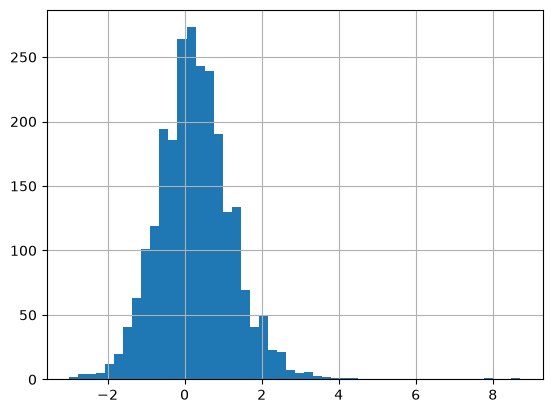

In [119]:
# Let's visualize how this looks like for all interactions  (across all cell types)
lr_res_skin = lr_res_skin.sort_values("interaction_stat", ascending=False)
lr_res_skin['interaction_stat'].hist(bins=50)

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_text : Removed 196 rows containing missing values.


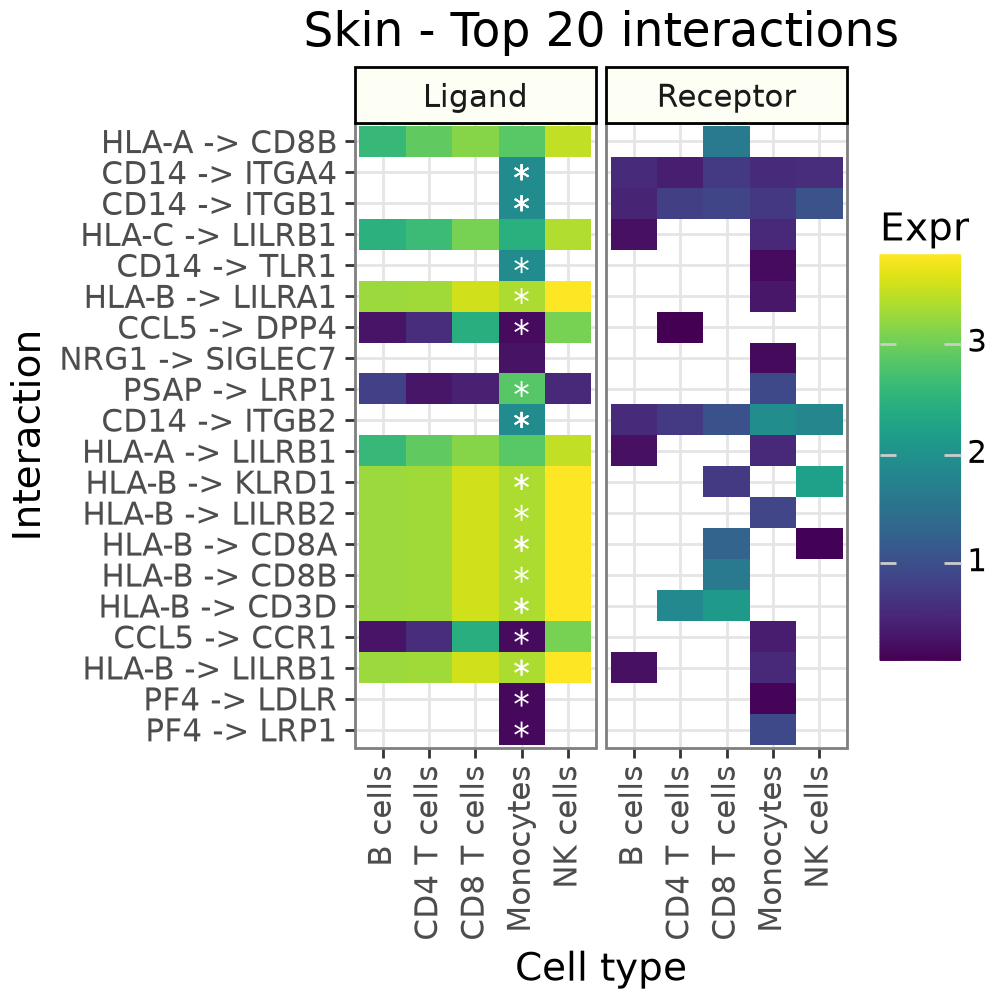

In [121]:
tile_plot = li.pl.tileplot(
    liana_res=lr_res_skin,
    fill='expr',
    label='padj',
    label_fun=lambda x: '*' if x < 0.05 else np.nan,
    top_n=20,
    orderby='interaction_stat',
    orderby_ascending=False,
    orderby_absolute=False,
    source_title='Ligand',
    target_title='Receptor',
)

tile_plot + p9.ggtitle(f"{object_skin} - Top 20 interactions")

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/plotnine/scales/scales.py:48: PlotnineWarning: Scale for 'color' is already present.
Adding another scale for 'color',
which will replace the existing scale.



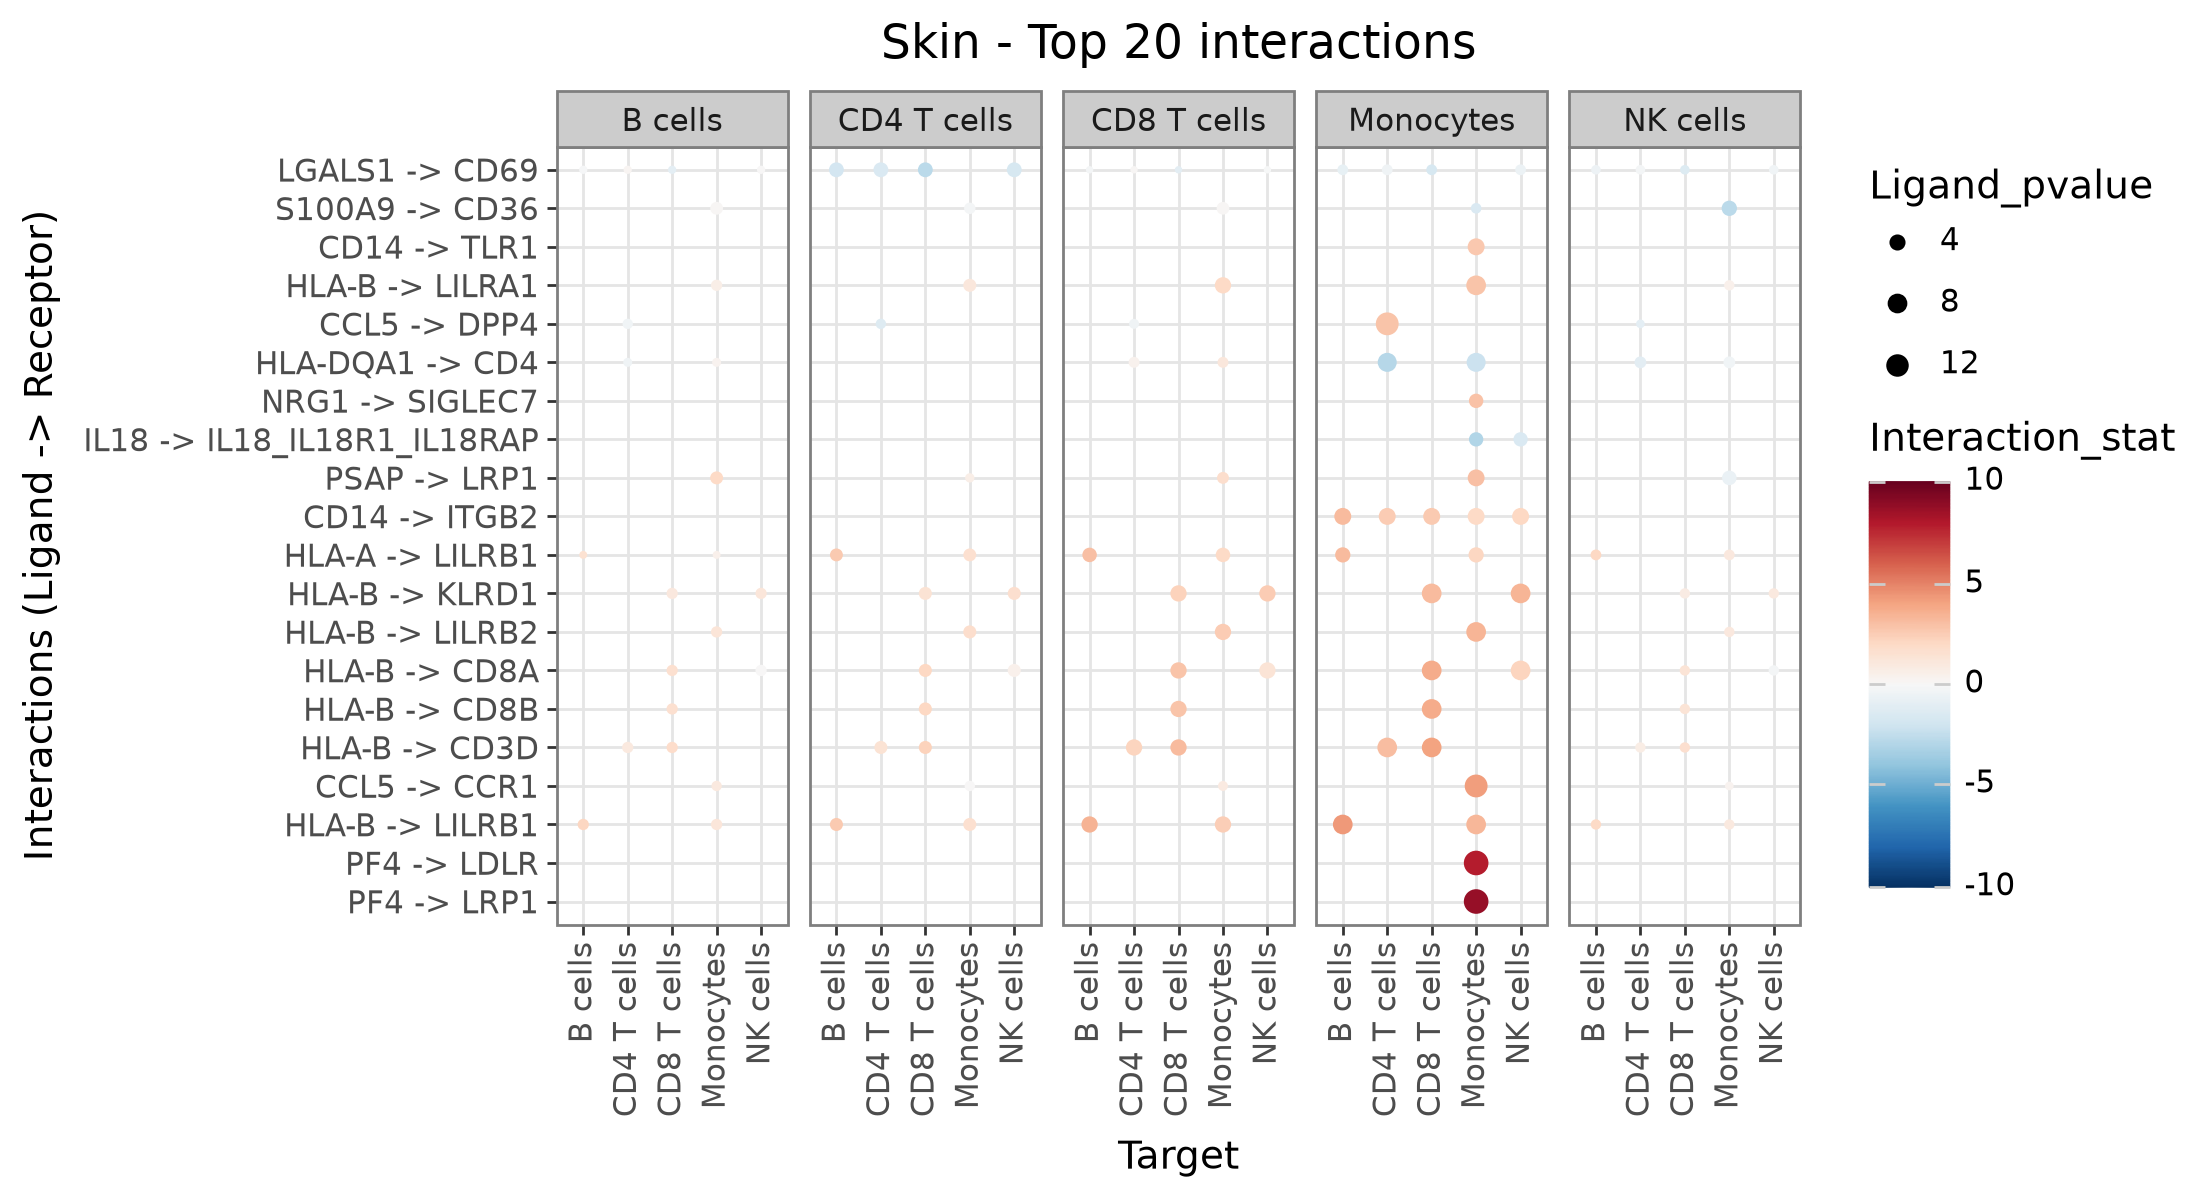

In [122]:
plot = li.pl.dotplot(
    liana_res=lr_res_skin,
    colour='interaction_stat',
    size='ligand_pvalue',
    inverse_size=True,
    orderby='interaction_stat',
    orderby_ascending=False,
    orderby_absolute=True,
    top_n=20,
    size_range=(0.5, 4)
)

(
    plot
    + p9.theme_bw(base_size=14)
    + p9.scale_color_cmap('RdBu_r', limits=(-10, 10))
    + p9.ggtitle(f"{object_skin} - Top 20 interactions")
    + p9.theme(
        axis_text_x=p9.element_text(angle=90),
        figure_size=(11, 6)
    )
)